# PPG 自适应滤波批处理实验 Notebook

本 notebook 用于按运动类型批量核验 PPG 心率估计流程，包括数据发现、质量检查、全局 Tdelay 静息段对齐诊断、未对齐 PPG-HR 测试图、Optuna 参数搜索、Stage-6 记录检查、Stage-7 replay、Stage-8 窗口诊断和 Stage-9 跨运动类型汇总。

重要约定：

- `TW_F` 是固定实验参数，只通过 `trial_param_overrides` 传入，不进入 Optuna/Bayes 搜索空间。
- `Alignment_TW` 只用于静息段 PPG-HR 提取和全局 Tdelay 搜索，不等同于训练窗口 `TW`。
- 不使用参考 HR 决定 `final_hr_bpm` 的融合选择；参考 HR 只用于评价和诊断对齐。
- 若心率曲线异常，建议先看第 3、4、6、10、11 部分的诊断图，再调整第 0 单元中的固定参数。


## 0. 初始化路径、依赖和全局默认参数

集中定义项目路径、导入当前协议 API，并固定本轮 notebook 工作流的非搜索参数。


In [2]:
# ===== 小白导读：第 0 块初始化 =====
# 作用：一次性设置 notebook 的“工作环境”，包括项目路径、Python 导入路径、输出目录和所有固定实验参数。
# 输入：本地仓库路径 PROJECT_ROOT、测试数据目录 TESTDATA_DIR，以及 src 中的 ppg_hr 源码。
# 输出：后续所有单元都会复用的全局变量，例如 RUN_OUTPUT_DIR、REST_HR_TRIAL_OVERRIDES、TW_F。
# 数据流向：这里定义的参数会传给第 3/4/6 节的诊断绘图，也会通过第 5 节 run_training_cell 进入训练流程。
# 使用范例：第一次打开 notebook 时先运行本单元；如果仓库移动，只改 PROJECT_ROOT；如果想改 TW_F，只改本单元的 TW_F。
# 关键提醒：TW_F、normalization_mode、qc_policy、Alignment_TW 等都是固定参数，不会进入 Optuna/Bayes 搜索空间。

from pathlib import Path
import json
import math
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

# 项目路径。若仓库移动，只需要同步修改 PROJECT_ROOT。
PROJECT_ROOT = Path(r"D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook")
SRC_DIR = PROJECT_ROOT / "src"
TESTDATA_DIR = PROJECT_ROOT / "testdata"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"

assert PROJECT_ROOT.exists(), f"项目根目录不存在: {PROJECT_ROOT}"
assert SRC_DIR.exists(), f"源码目录不存在: {SRC_DIR}"
assert TESTDATA_DIR.exists(), f"测试数据目录不存在: {TESTDATA_DIR}"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    import optuna
    print("optuna", optuna.__version__)
except ModuleNotFoundError:
    optuna = None
    print("未安装 optuna，训练时会使用项目内置 fallback。")

from ppg_hr.experimental.alignment import align_ppg_to_ref_hr
from ppg_hr.experimental.batch_pairing import discover_sample_pairs_with_unpaired
from ppg_hr.experimental.preprocess_protocol import load_and_preprocess_protocol, resample_protocol_dataset
from ppg_hr.experimental.qc import quality_filter_sample
from ppg_hr.experimental.protocol_outputs import (
    plot_rest_alignment_diagnostics_by_motion_type,
    plot_raw_ppg_and_unaligned_hr_by_motion_type,
    plot_unaligned_fullfield_ppg_hr_by_motion_type,
)
from ppg_hr.experimental.protocol_search_space import ProtocolTrialParams
from ppg_hr.experimental.run_batch_protocol import (
    build_cross_motion_summary_table,
    build_output_run_name,
    plot_window_diagnostics_from_records,
    replay_best_record_hr_curves,
    run_batch_adaptive_protocol,
    safe_prepare_output_dir,
)
from ppg_hr.experimental.segmentation import detect_activity_segments
from ppg_hr.params import CascadeScheme, ProtocolSearchParams, TargetScope

# 全局固定参数。
FS_ORIGIN = 100
RANDOM_STATE = 42
TW_F = 0.0
NORMALIZATION_MODE = "minmax"
QC_POLICY = "fallback_baseline"
ALIGNMENT_TW = 8.0
ALIGNMENT_STEP_S = 1.0
OPTIMIZATION_OBJECTIVE = "accuracy"
DATA_SPLIT_MODE = "all_train"
DELAY_ESTIMATION_MODE = "envelope"
ENABLE_TIME_BIAS_AFTER = True
TIME_BIAS_AFTER_RANGE_S = (-5.0, 5.0)
TIME_BIAS_AFTER_STEP_S = 1.0
RECOVERY_GRACE_S = 15.0
RECOVERY_DIFF_BPM = 150.0
RECOVERY_CROSS_DIFF_BPM = 8.0

CLEAN_OUTPUTS = True
VAL_GROUPS_PER_TYPE = 1
TEST_GROUPS_PER_TYPE = 1
REST_ALIGNMENT_SCORE_MODE = "aae"
TIME_BIAS_AFTER_MODE = "posthoc_oracle_alignment"

# 静息段 PPG-HR 后处理参数。PPG/HF/CF/ACC 的分类型带通在源码中保持原有配置。
REST_HR_BAND_BPM = (40.0, 180.0)
REST_HR_BAND_HZ = tuple(v / 60.0 for v in REST_HR_BAND_BPM)
REST_HR_TRACK_BAND_BPM = 30.0
REST_HR_SLEW_LIMIT_BPM = 4.0
REST_HR_SLEW_STEP_BPM = 2.0
REST_HR_SMOOTH_METHOD = "median"
REST_HR_SMOOTH_WIN = 7
REST_HR_PEAK_PERCENT = 0.3
REST_HR_SPEC_PENALTY_ENABLE = True
REST_HR_SPEC_PENALTY_WEIGHT = 0.2
REST_HR_SPEC_PENALTY_WIDTH_HZ = 0.2

# TW_F 是固定实验参数，不进入 Optuna/Bayes 搜索空间。
# Alignment_TW 只用于静息段全局 Tdelay，不要误用为训练窗口 TW。
REST_HR_KWARGS = {
    "hr_band_bpm": REST_HR_BAND_BPM,
    "track_band_bpm": REST_HR_TRACK_BAND_BPM,
    "slew_limit_bpm": REST_HR_SLEW_LIMIT_BPM,
    "slew_step_bpm": REST_HR_SLEW_STEP_BPM,
    "smooth_method": REST_HR_SMOOTH_METHOD,
    "smooth_win": REST_HR_SMOOTH_WIN,
    "peak_percent": REST_HR_PEAK_PERCENT,
    "spec_penalty_enable": REST_HR_SPEC_PENALTY_ENABLE,
    "spec_penalty_weight": REST_HR_SPEC_PENALTY_WEIGHT,
    "spec_penalty_width_hz": REST_HR_SPEC_PENALTY_WIDTH_HZ,
}
REST_HR_TRIAL_OVERRIDES = {
    "TW_F": TW_F,
    "normalization_mode": NORMALIZATION_MODE,
    "qc_policy": QC_POLICY,
    "delay_estimation_mode": DELAY_ESTIMATION_MODE,
    "Alignment_TW": ALIGNMENT_TW,
    "Alignment_Step": ALIGNMENT_STEP_S,
    "Rest_HR_Band_BPM": REST_HR_BAND_BPM,
    "Rest_HR_Track_Band_BPM": REST_HR_TRACK_BAND_BPM,
    "Rest_HR_Slew_Limit_BPM": REST_HR_SLEW_LIMIT_BPM,
    "Rest_HR_Slew_Step_BPM": REST_HR_SLEW_STEP_BPM,
    "Rest_HR_Smooth_Method": REST_HR_SMOOTH_METHOD,
    "Rest_HR_Smooth_Win": REST_HR_SMOOTH_WIN,
    "Rest_HR_Peak_Percent": REST_HR_PEAK_PERCENT,
    "Rest_HR_Spec_Penalty_Enable": REST_HR_SPEC_PENALTY_ENABLE,
    "Rest_HR_Spec_Penalty_Weight": REST_HR_SPEC_PENALTY_WEIGHT,
    "Rest_HR_Spec_Penalty_Width_Hz": REST_HR_SPEC_PENALTY_WIDTH_HZ,
    "Rest_Alignment_Score_Mode": REST_ALIGNMENT_SCORE_MODE,
    "Enable_Time_Bias_After": ENABLE_TIME_BIAS_AFTER,
    "Time_Bias_After_Range_S": TIME_BIAS_AFTER_RANGE_S,
    "Time_Bias_After_Step_S": TIME_BIAS_AFTER_STEP_S,
    "Time_Bias_After_Mode": TIME_BIAS_AFTER_MODE,
    "Recovery_Grace_S": RECOVERY_GRACE_S,
    "Recovery_Diff_Bpm": RECOVERY_DIFF_BPM,
    "Recovery_Cross_Diff_Bpm": RECOVERY_CROSS_DIFF_BPM,
}

# 默认训练组合。正式训练时可在第 7、8 单元覆盖。
ACTIVE_TARGET_SCOPES = ["global"] if "global" in [item.value for item in TargetScope] else ["motion_post10"]
ACTIVE_CASCADE_SCHEMES = ["ACC3"]
ACTIVE_ADAPTIVE_FILTERS = ["lms"]
CASCADE_TRAIN_BUDGETS = {scheme: {"n_trials": 1, "n_repeats": 1} for scheme in ACTIVE_CASCADE_SCHEMES}


def make_unique_output_dir(
    target_scopes,
    cascade_schemes,
    adaptive_filters,
    objective_mode,
    split_mode,
    *,
    tw_f=TW_F,
):
    '''根据当前训练配置创建唯一输出目录，避免覆盖已有实验结果。'''
    base_name = build_output_run_name(
        target_scopes,
        cascade_schemes,
        adaptive_filters,
        objective_mode,
        split_mode,
        tw_f_s=float(tw_f),
    )
    run_name = base_name
    run_dir = OUTPUT_ROOT / run_name
    if not CLEAN_OUTPUTS:
        idx = 1
        while run_dir.exists() and any(run_dir.iterdir()):
            run_name = f"{base_name}__run{idx:02d}"
            run_dir = OUTPUT_ROOT / run_name
            idx += 1
    run_dir = safe_prepare_output_dir(
        project_root=PROJECT_ROOT,
        output_dir=run_dir,
        clean_outputs=CLEAN_OUTPUTS,
    )
    return run_name, run_dir


OUTPUT_RUN_NAME, RUN_OUTPUT_DIR = make_unique_output_dir(
    ACTIVE_TARGET_SCOPES,
    ACTIVE_CASCADE_SCHEMES,
    ACTIVE_ADAPTIVE_FILTERS,
    OPTIMIZATION_OBJECTIVE,
    DATA_SPLIT_MODE,
    tw_f=TW_F,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)
print("TESTDATA_DIR:", TESTDATA_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("OUTPUT_RUN_NAME:", OUTPUT_RUN_NAME)
print("RUN_OUTPUT_DIR:", RUN_OUTPUT_DIR)
print("REST_HR_TRIAL_OVERRIDES:", REST_HR_TRIAL_OVERRIDES)


optuna 4.8.0
PROJECT_ROOT: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook
SRC_DIR: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\src
TESTDATA_DIR: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\testdata
OUTPUT_ROOT: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs
OUTPUT_RUN_NAME: global__ACC3__lms__accuracy__all_train__TW_F0s
RUN_OUTPUT_DIR: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\global__ACC3__lms__accuracy__all_train__TW_F0s
REST_HR_TRIAL_OVERRIDES: {'TW_F': 0.0, 'normalization_mode': 'minmax', 'qc_policy': 'fallback_baseline', 'delay_estimation_mode': 'envelope', 'Alignment_TW': 8.0, 'Alignment_Step': 1.0, 'Rest_HR_Band_BPM': (40.0, 180.0), 'Rest_HR_Track_Band_BPM': 30.0, 'Rest_HR_Slew_Limit_BPM': 4.0, 'Rest_HR_Slew_Step_BPM': 2.0, 'Rest_HR_Smooth_Method': 'median', 'Rest_HR_Smooth_Win': 7, 'Rest_HR_Peak_Percent': 0.3, 'Rest_HR_Spec_Penalty_Enable': True, 'Rest_HR_Spec_Penalty_Weight': 0.2, 'Rest_HR_S

## 1. 发现样本配对并执行 QC

发现 `testdata` 中的传感器 CSV 与 `_ref.csv` 配对，执行基础 QC，并额外验证新格式 `multi_tiaosheng1.csv` 的清洗后字段与 QC/元数据列。


In [3]:
# ===== 小白导读：第 1 块发现样本与 QC =====
# 作用：自动查找 testdata 下的 multi_<运动类型><编号>.csv 与对应 _ref.csv，并做基础质量检查。
# 输入：TESTDATA_DIR 中的原始传感器 CSV 和参考心率 CSV；文件名必须能被 discover_sample_pairs_with_unpaired 识别。
# 输出：good_pairs 是通过 QC 的样本列表；bad_pairs 是未通过 QC 的样本；qc_df/unpaired_df 用于人工排错。
# 数据流向：good_pairs 会被第 2/3/4/6 节绘图和第 7/8 节训练继续使用。
# 使用范例：运行后先看 good_pairs 和 qc_df；如果某个样本缺失 ref，会出现在 unpaired_df 中。
# 关键参数：FS_ORIGIN 是原始采样率；QC_METADATA_COLUMNS 是希望在新格式 CSV 中看到的元数据列。

discovery = discover_sample_pairs_with_unpaired(TESTDATA_DIR)


def _pairs_to_frame(pairs):
    return pd.DataFrame([
        {
            "group_id": p.motion_id,
            "motion_type": p.motion_type,
            "motion_index": p.motion_index,
            "data_file": p.sensor_csv.name,
            "ref_file": p.ref_csv.name,
        }
        for p in pairs
    ])


pairs_df = _pairs_to_frame(discovery.pairs)
unpaired_df = pd.DataFrame([
    {"file_name": u.file_name, "file_path": str(u.file_path), "reason": u.reason}
    for u in discovery.unpaired
])

qc_rows = []
good_pairs = []
bad_pairs = []
for pair in discovery.pairs:
    qc = quality_filter_sample(
        pair.sensor_csv,
        fs=FS_ORIGIN,
        group_id=pair.motion_id,
        motion_type=pair.motion_type,
        ref_csv=pair.ref_csv,
    )
    qc_rows.append(qc.to_dict())
    if qc.is_good:
        good_pairs.append(pair)
    else:
        bad_pairs.append(pair)
qc_df = pd.DataFrame(qc_rows)
good_pairs_df = _pairs_to_frame(good_pairs)
bad_pairs_df = _pairs_to_frame(bad_pairs)

print("已配对样本数:", len(discovery.pairs))
print("未配对文件数:", len(discovery.unpaired))
print("通过 QC 样本数:", len(good_pairs))
print("未通过 QC 样本数:", len(bad_pairs))
print("good_pairs:", [p.motion_id for p in good_pairs])
print("bad_pairs:", [p.motion_id for p in bad_pairs])
print("检测到的运动类型:", sorted(pairs_df["motion_type"].unique()) if not pairs_df.empty else [])

display(good_pairs_df)
display(bad_pairs_df)
display(unpaired_df)
display(qc_df)

# 新格式读取验证：优先读取 multi_tiaosheng1.csv；若未通过 QC，则退回第一个 good sample。
validation_pair = next((p for p in good_pairs if p.sensor_csv.name == "multi_tiaosheng1.csv"), None)
if validation_pair is None and good_pairs:
    validation_pair = good_pairs[0]

QC_METADATA_COLUMNS = [
    "SampleIndex",
    "Seq",
    "ValidFlag",
    "InterpFlag",
    "GapLen",
    "MissingBefore",
    "raw_missing_any",
    "raw_missing_count",
]

if validation_pair is None:
    print("没有通过 QC 的样本，无法执行新格式读取验证。")
else:
    validation_dataset = load_and_preprocess_protocol(
        validation_pair.sensor_csv,
        validation_pair.ref_csv,
        fs_origin=FS_ORIGIN,
    )
    validation_frame = validation_dataset.to_frame()
    key_columns = [
        "time_s",
        "ppg_green",
        "hf1",
        "cf1",
        "accx",
        *QC_METADATA_COLUMNS,
    ]
    existing_key_columns = [c for c in key_columns if c in validation_frame.columns]
    print("新格式读取验证样本:", validation_pair.sensor_csv.name)
    display(validation_frame.loc[:, existing_key_columns].head())
    qc_metadata_check = pd.DataFrame([
        {
            "column": column,
            "exists": column in validation_frame.columns,
            "non_null_count": int(validation_frame[column].notna().sum()) if column in validation_frame.columns else 0,
        }
        for column in QC_METADATA_COLUMNS
    ])
    display(qc_metadata_check)


已配对样本数: 5
未配对文件数: 0
通过 QC 样本数: 5
未通过 QC 样本数: 0
good_pairs: ['tiaosheng1', 'tiaosheng2', 'tiaosheng3', 'tiaosheng4', 'tiaosheng5']
bad_pairs: []
检测到的运动类型: ['tiaosheng']


,group_id,motion_type,motion_index,data_file,ref_file
0,tiaosheng1,tiaosheng,1,multi_tiaosheng1.csv,multi_tiaosheng1_ref.csv
1,tiaosheng2,tiaosheng,2,multi_tiaosheng2.csv,multi_tiaosheng2_ref.csv
2,tiaosheng3,tiaosheng,3,multi_tiaosheng3.csv,multi_tiaosheng3_ref.csv
3,tiaosheng4,tiaosheng,4,multi_tiaosheng4.csv,multi_tiaosheng4_HR_ref.csv
4,tiaosheng5,tiaosheng,5,multi_tiaosheng5.csv,multi_tiaosheng5_HR_ref.csv


""


""


,group_id,motion_type,data_file,ref_file,file_name,status,reason,std_ut1,std_ut2,outlier_count_ut1,outlier_count_ut2,outlier_ratio_ut1,outlier_ratio_ut2,is_good
0,tiaosheng1,tiaosheng,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,multi_tiaosheng1.csv,good,ok,0.281450,0.155847,7,13,0.007,0.013,True
1,tiaosheng2,tiaosheng,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,multi_tiaosheng2.csv,good,ok,0.336994,0.174752,5,12,0.005,0.012,True
2,tiaosheng3,tiaosheng,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,multi_tiaosheng3.csv,good,ok,0.354486,0.232319,4,2,0.004,0.002,True
3,tiaosheng4,tiaosheng,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,multi_tiaosheng4.csv,good,ok,0.160617,0.167922,10,8,0.010,0.008,True
4,tiaosheng5,tiaosheng,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGt...,multi_tiaosheng5.csv,good,ok,0.223649,0.154485,11,6,0.011,0.006,True


新格式读取验证样本: multi_tiaosheng1.csv


,time_s,ppg_green,hf1,cf1,accx,SampleIndex,Seq,ValidFlag,InterpFlag,GapLen,MissingBefore,raw_missing_any,raw_missing_count
0,0.00,-3.885700,-0.049570,0.000287,-0.000548,0,19847,1,0,0,0,0,0
1,0.01,-4.287346,-0.122940,0.000200,0.001832,1,19848,1,0,0,0,0,0
2,0.02,-4.658004,-0.192152,0.000113,0.004080,2,19849,1,0,0,0,0,0
3,0.03,-4.973586,-0.253463,0.000028,0.006087,3,19850,1,0,0,0,0,0
4,0.04,-5.212485,-0.303547,-0.000053,0.007780,4,19851,1,0,0,0,0,0


,column,exists,non_null_count
0,SampleIndex,True,21103
1,Seq,True,21103
2,ValidFlag,True,21103
3,InterpFlag,True,21103
4,GapLen,True,21103
5,MissingBefore,True,21103
6,raw_missing_any,True,21103
7,raw_missing_count,True,21103


## 2. 单样本预处理、分段和全局对齐预览

使用 `good_pairs[0]` 做 smoke preview：预处理、重采样、ACC 分段，以及固定 `ALIGNMENT_TW` 的全局 Tdelay 对齐。


In [4]:
# ===== 小白导读：第 2 块单样本预览 =====
# 作用：拿第一个 good sample 做快速体检，确认数据能加载、能重采样、能分段、能估计全局 Tdelay。
# 输入：good_pairs[0] 对应的一对传感器/参考心率文件，以及第 0 块定义的 ALIGNMENT_TW/ALIGNMENT_STEP_S。
# 输出：一个小表格，展示 motion_start_s、motion_end_s、best_tdelay_s 和 rest/motion/recovery 窗口数量。
# 数据流向：本单元只做预览，不会写训练结果；如果这里失败，后面训练通常也需要先排查。
# 使用范例：如果想预览其他样本，可以把 pair = good_pairs[0] 改成 good_pairs[1] 或指定某个 motion_id。
# 关键提醒：preview_train_TW 只模拟训练窗口长度；全局静息段对齐仍使用 ALIGNMENT_TW，二者不要混用。

if good_pairs:
    pair = good_pairs[0]
    ds = load_and_preprocess_protocol(pair.sensor_csv, pair.ref_csv, fs_origin=FS_ORIGIN)
    ds = resample_protocol_dataset(ds, fs_target=100)

    preview_train_TW = 8
    seg = detect_activity_segments(ds.accx, ds.accy, ds.accz, ds.fs, TW=preview_train_TW)
    if not seg.is_valid:
        print(f"分段失败: {pair.stem}: {seg.reason}")
    else:
        aligned = align_ppg_to_ref_hr(
            ds,
            seg,
            TW=preview_train_TW,
            fs_target=ds.fs,
            alignment_TW=ALIGNMENT_TW,
            alignment_step_s=ALIGNMENT_STEP_S,
            rest_hr_kwargs=REST_HR_KWARGS,
            alignment_score_mode=REST_ALIGNMENT_SCORE_MODE,
        )
        preview_row = {
            "sample": pair.stem,
            "motion_type": pair.motion_type,
            "fs": ds.fs,
            "motion_start_s": aligned.segment_info.motion_start_s,
            "motion_end_s": aligned.segment_info.motion_end_s,
            "alignment_TW": aligned.alignment_info.alignment_tw_s,
            "train_TW": aligned.alignment_info.train_tw_s,
            "best_tdelay_s": aligned.alignment_info.best_tdelay_s,
            "rest_windows": len(aligned.rest_indices),
            "motion_windows": len(aligned.motion_indices),
            "recovery_windows": len(aligned.recovery_indices),
        }
        display(pd.DataFrame([preview_row]))
else:
    print("没有通过 QC 的样本，后续训练无法继续。")


[alignment] multi_tiaosheng1: best_tdelay_s=5.0, rest_windows=45


,sample,motion_type,fs,motion_start_s,motion_end_s,alignment_TW,train_TW,best_tdelay_s,rest_windows,motion_windows,recovery_windows
0,multi_tiaosheng1,tiaosheng,100,48.0,120.0,8.0,8.0,5.0,44,73,82


## 3. 输出全局 Tdelay 静息段对齐诊断图（Alignment_TW=8）

每个运动类型输出一张静息段对齐诊断图，用于人工核查固定 `Alignment_TW=8.0` 下的全局 Tdelay。


[alignment] multi_tiaosheng2: best_tdelay_s=-3.1, rest_windows=45
[alignment] multi_tiaosheng3: best_tdelay_s=-0.7, rest_windows=46
[alignment] multi_tiaosheng4: best_tdelay_s=-3.7, rest_windows=54
[alignment] multi_tiaosheng5: best_tdelay_s=-3.9, rest_windows=45
alignment_diagnostics: {'tiaosheng': WindowsPath('D:/data/PPG_HeartRate/Algorithm/Algorithm/PPGtoHR_notebook/outputs/global__ACC3__lms__accuracy__all_train__TW_F0s/alignment_diagnostics/tiaosheng_rest_alignment_TW8.png')}


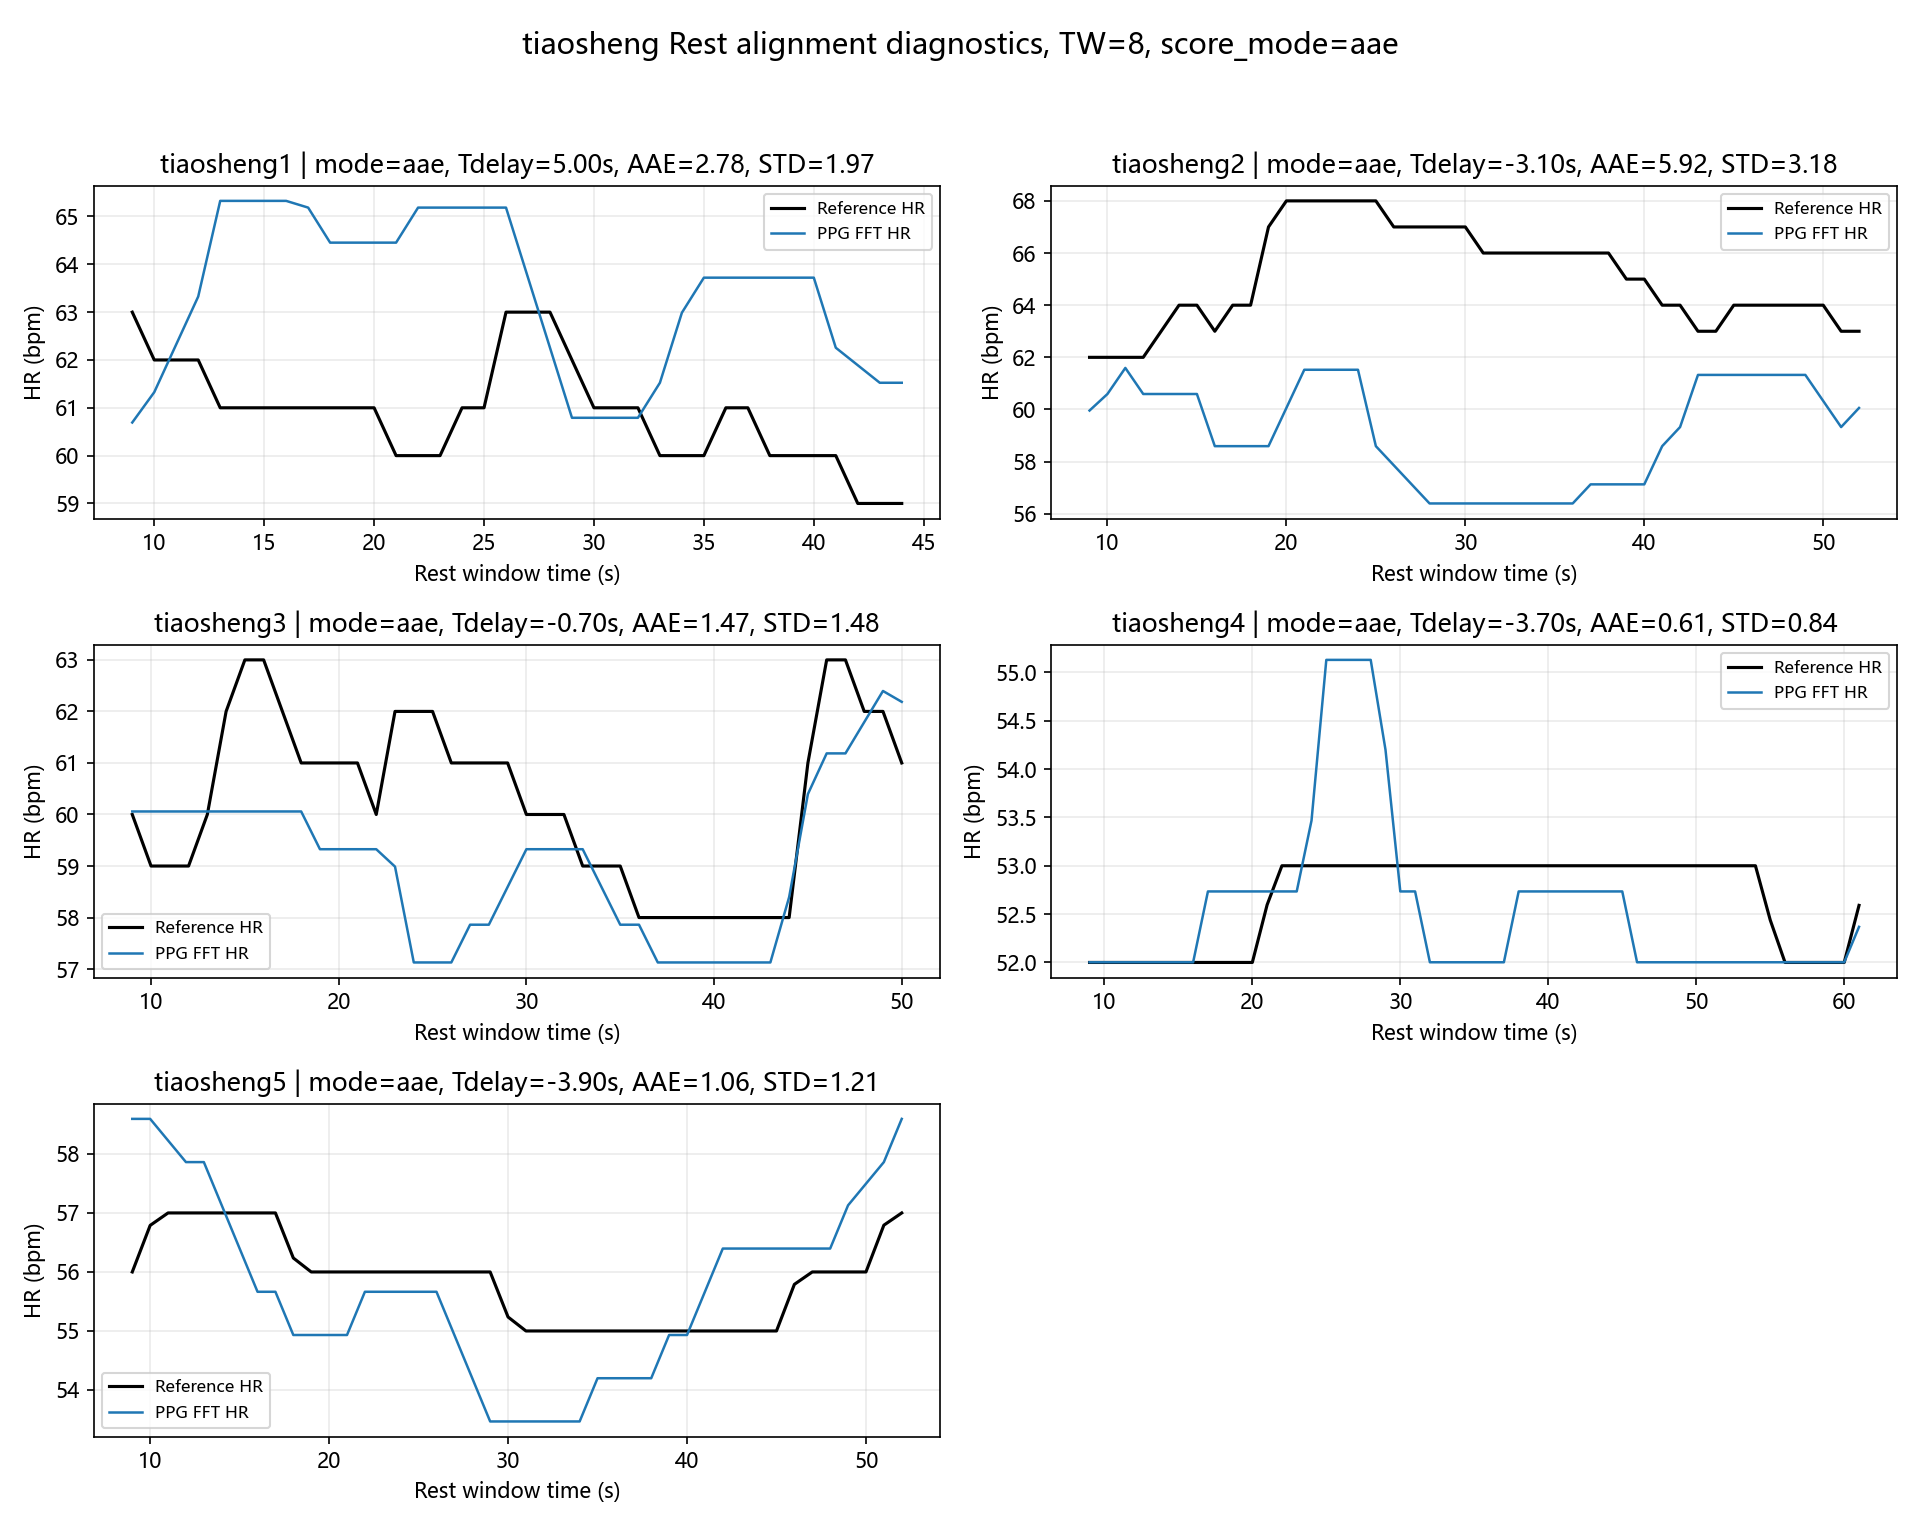

In [5]:
# ===== 小白导读：第 3 块静息段 Tdelay 诊断图 =====
# 作用：按运动类型生成静息段 PPG-HR 与参考 HR 的对齐诊断图，检查全局 Tdelay 是否合理。
# 输入：good_pairs、原始数据集、ALIGNMENT_TW=8.0，以及 REST_HR_KWARGS 中的静息 HR 提取参数。
# 输出：alignment_diagnostic_paths 字典，键是运动类型，值是生成的 PNG 图片路径。
# 数据流向：这些图片只用于人工判断，不会反过来改变训练参数或 final_hr_bpm 融合逻辑。
# 使用范例：运行后逐张看图；如果静息段 HR 偏离严重，优先回第 0 块调整 REST_HR_* 参数。
# 关键参数：alignment_TW 决定静息段 FFT 窗口长度；alignment_step_s 决定搜索窗口步长。

assert float(ALIGNMENT_TW) == 8.0, f"本诊断要求 ALIGNMENT_TW=8.0，当前为 {ALIGNMENT_TW}"
ALIGNMENT_DIAGNOSTIC_DIR = RUN_OUTPUT_DIR / "alignment_diagnostics"

alignment_diagnostic_datasets = {}
for pair in good_pairs:
    try:
        alignment_diagnostic_datasets[pair.motion_id] = load_and_preprocess_protocol(
            pair.sensor_csv,
            pair.ref_csv,
            fs_origin=FS_ORIGIN,
        )
    except Exception as exc:
        print(f"alignment diagnostic preprocessing failed: {pair.motion_id}: {exc}")

alignment_diagnostic_paths = plot_rest_alignment_diagnostics_by_motion_type(
    pairs=good_pairs,
    datasets=alignment_diagnostic_datasets,
    output_dir=ALIGNMENT_DIAGNOSTIC_DIR,
    fs_target=100,
    TW=int(ALIGNMENT_TW),
    alignment_TW=ALIGNMENT_TW,
    alignment_step_s=ALIGNMENT_STEP_S,
    rest_hr_kwargs=REST_HR_KWARGS,
    alignment_score_mode=REST_ALIGNMENT_SCORE_MODE,
)
print("alignment_diagnostics:", alignment_diagnostic_paths)
for image_path in alignment_diagnostic_paths.values():
    display(Image(filename=str(image_path)))


## 4. 输出全段未对齐 PPG-HR 测试图

不做全局 Tdelay 对齐，直接对完整 PPG_Green 分窗提取 PPG-HR，用于判断异常是否来自原始 PPG 主频、分段位置或后处理参数。


fullfield_ppg_hr_paths: {'tiaosheng': WindowsPath('D:/data/PPG_HeartRate/Algorithm/Algorithm/PPGtoHR_notebook/outputs/allfield/tiaosheng_all_alignment_TW8.png')}


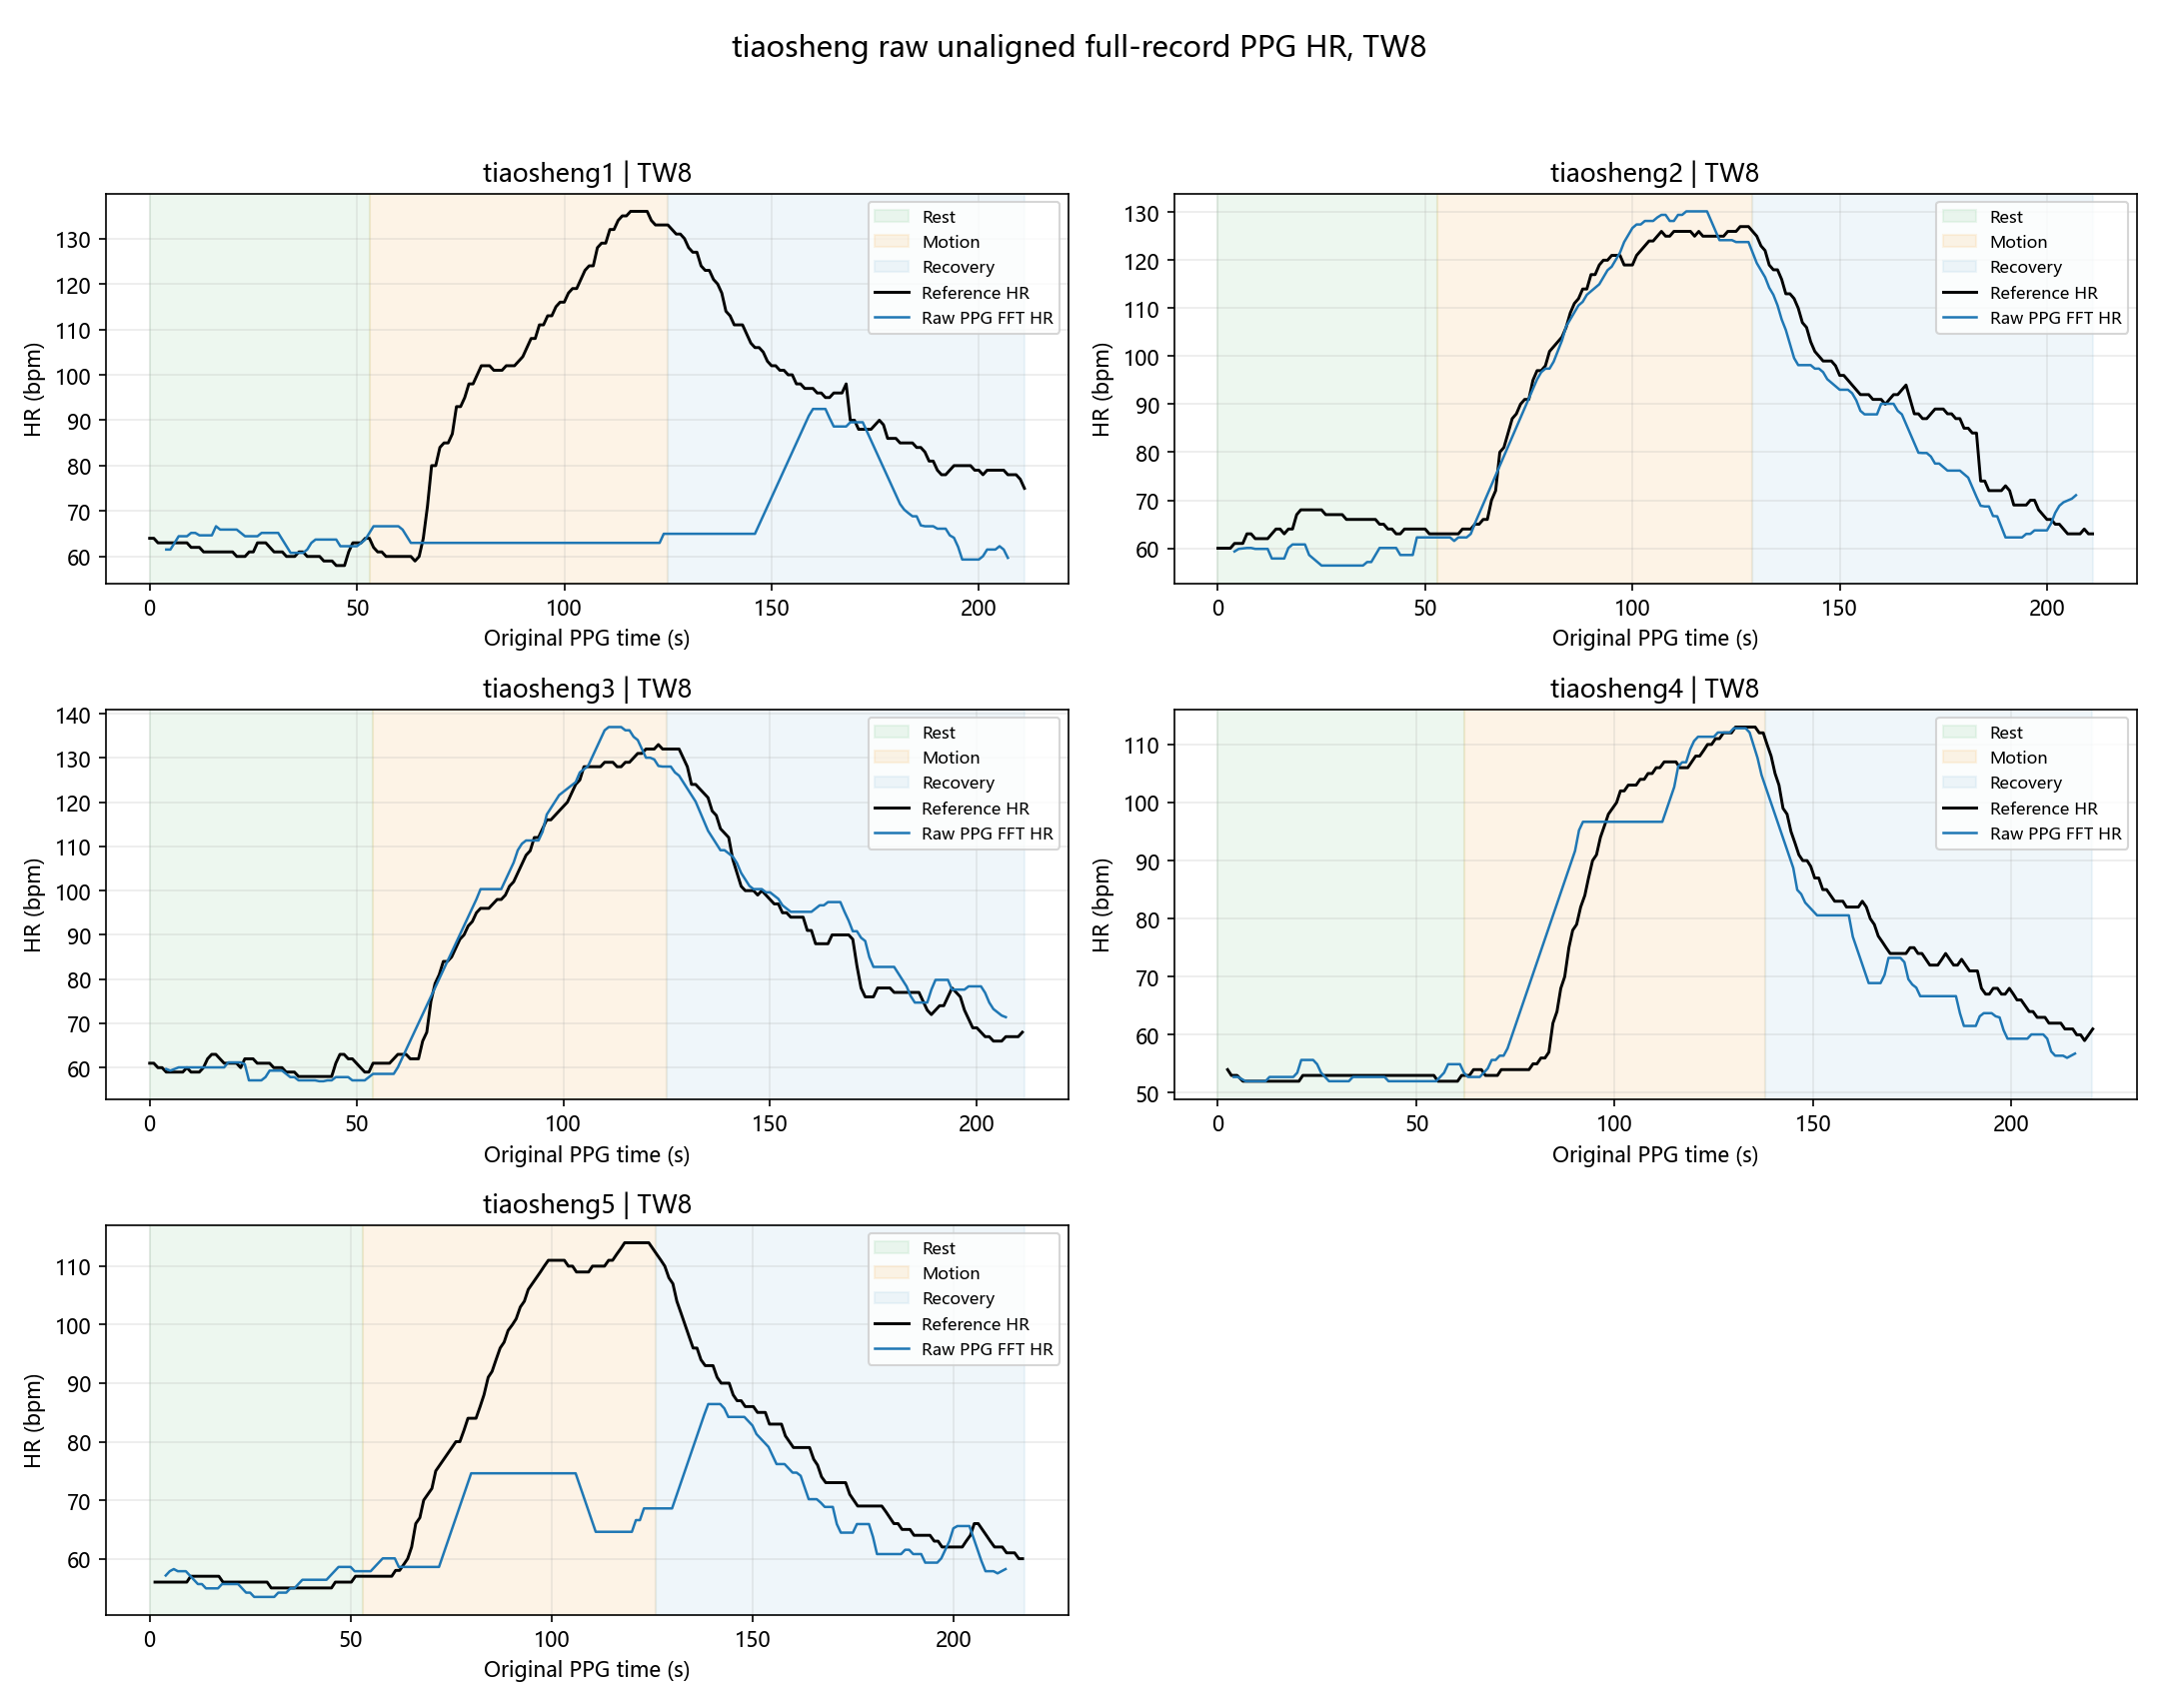

In [6]:
# ===== 小白导读：第 4 块全段未对齐 PPG-HR 图 =====
# 作用：不做 Tdelay 对齐，直接在完整 PPG_Green 上分窗提取 HR，帮助判断原始 PPG 主频是否可信。
# 输入：good_pairs、前面已加载的数据集，以及 REST_HR_BAND_HZ/track/slew/smooth 等 HR 后处理参数。
# 输出：fullfield_ppg_hr_paths 字典，里面是每个运动类型对应的全段未对齐 PPG-HR PNG。
# 数据流向：本单元复用第 3 块的数据，缺失时自动补加载；结果只用于人工诊断。
# 使用范例：如果某运动类型训练效果差，先看这里原始 PPG-HR 是否已经明显跳变或偏频。
# 关键参数：FULLFIELD_PPG_HR_TW 默认等于 ALIGNMENT_TW，便于和静息段诊断窗口保持一致。

FULLFIELD_PPG_HR_DIR = OUTPUT_ROOT / "allfield"
FULLFIELD_PPG_HR_TW = int(ALIGNMENT_TW)

fullfield_ppg_hr_datasets = dict(globals().get("alignment_diagnostic_datasets", {}))
for pair in good_pairs:
    if pair.motion_id in fullfield_ppg_hr_datasets:
        continue
    try:
        fullfield_ppg_hr_datasets[pair.motion_id] = load_and_preprocess_protocol(
            pair.sensor_csv,
            pair.ref_csv,
            fs_origin=FS_ORIGIN,
        )
    except Exception as exc:
        print(f"fullfield PPG-HR preprocessing failed: {pair.motion_id}: {exc}")

fullfield_ppg_hr_paths = plot_unaligned_fullfield_ppg_hr_by_motion_type(
    pairs=good_pairs,
    datasets=fullfield_ppg_hr_datasets,
    output_dir=FULLFIELD_PPG_HR_DIR,
    fs_target=100,
    TW=FULLFIELD_PPG_HR_TW,
    hr_band_hz=REST_HR_BAND_HZ,
    track_band_bpm=REST_HR_TRACK_BAND_BPM,
    slew_limit_bpm=REST_HR_SLEW_LIMIT_BPM,
    slew_step_bpm=REST_HR_SLEW_STEP_BPM,
    smooth_method=REST_HR_SMOOTH_METHOD,
    smooth_win=REST_HR_SMOOTH_WIN,
    peak_percent=REST_HR_PEAK_PERCENT,
    spec_penalty_enable=REST_HR_SPEC_PENALTY_ENABLE,
    spec_penalty_weight=REST_HR_SPEC_PENALTY_WEIGHT,
    spec_penalty_width_hz=REST_HR_SPEC_PENALTY_WIDTH_HZ,
)
print("fullfield_ppg_hr_paths:", fullfield_ppg_hr_paths)
for image_path in fullfield_ppg_hr_paths.values():
    display(Image(filename=str(image_path)))


## 5. 封装训练函数

封装训练预算、notebook 进度输出和统一训练入口。`TW_F`、`normalization_mode`、`qc_policy` 只作为固定参数进入 `ProtocolTrialParams`，不进入搜索空间。


In [7]:
# ===== 小白导读：第 5 块训练函数封装 =====
# 作用：把训练入口包装成 run_training_cell，后续第 7/8 块只需要填组合和预算即可启动。
# 输入：target_scopes、cascade_schemes、adaptive_filters、cascade_train_budgets，以及固定参数 TW_F/normalization/qc_policy。
# 输出：BatchProtocolResult 对象，里面包含 output_root、motion_type_dirs、summary CSV 路径等结果入口。
# 数据流向：本函数调用 run_batch_adaptive_protocol；trial_param_overrides 会转成 ProtocolTrialParams 固定字段。
# 使用范例：第 7 块 all_train 会调用它；如果只想测试 ACC3+lms，把 ACTIVE_CASCADE_SCHEMES 和 ACTIVE_ADAPTIVE_FILTERS 保持当前值。
# 关键提醒：CASCADE_TRAIN_BUDGETS 控制每个 cascade_scheme 的 n_trials/n_repeats；TW_F 只是固定实验参数，不参与搜索。

def make_budgets(schemes, n_trials=1, n_repeats=1):
    '''为每个 cascade scheme 生成相同的 Optuna 搜索预算。'''
    return {scheme: {"n_trials": int(n_trials), "n_repeats": int(n_repeats)} for scheme in schemes}


PROGRESS_EVERY_N_TRIALS = 10


def notebook_progress(info):
    '''Notebook 进度回调：只打印关键 trial，避免长时间训练刷屏。'''
    stage = info.get("stage", "")
    if stage == "optimization":
        trial_idx = int(info.get("trial_idx") or 0)
        trial_total = int(info.get("trial_total") or 0)
        if trial_idx == 1 or trial_idx == trial_total or trial_idx % PROGRESS_EVERY_N_TRIALS == 0:
            print(
                f"motion_type {info.get('motion_type')} | "
                f"mode {info.get('mode_idx')}/{info.get('mode_total')} | "
                f"{info.get('target_scope_value')} / {info.get('cascade_scheme')} / {info.get('adaptive_filter')} | "
                f"repeat {info.get('repeat_idx')}/{info.get('repeat_total')} | "
                f"trial {trial_idx}/{trial_total} | "
                f"AAE {info.get('aae_bpm')} | accuracy {info.get('accuracy_pct')} | "
                f"objective_mode {info.get('objective_mode')} | objective_value {info.get('objective_value')}"
            )
    elif stage == "optimization_mode":
        print(
            f"enter mode {info.get('mode_idx')}/{info.get('mode_total')}: "
            f"{info.get('motion_type')} / {info.get('target_scope_value')} / "
            f"{info.get('cascade_scheme')} / {info.get('adaptive_filter')}"
        )
    elif stage == "optimization_parallel_repeats_start":
        print(
            f"parallel repeats start: n_jobs={info.get('n_jobs')}, repeats={info.get('repeat_total')} | "
            f"{info.get('motion_type')} / {info.get('target_scope_value')} / "
            f"{info.get('cascade_scheme')} / {info.get('adaptive_filter')} / fold={info.get('fold_id')}"
        )
    elif stage == "optimization_parallel_repeat_done":
        print(
            f"repeat {info.get('repeat_current')}/{info.get('repeat_total')} done "
            f"({info.get('repeat_done')}/{info.get('repeat_total')} completed), "
            f"best={info.get('best_value'):.4f}, global_best={info.get('global_best_value'):.4f}"
        )
    elif stage in {"qc", "preprocess"}:
        print(f"{stage} {info.get('current')}/{info.get('total')}: {info.get('sample')}")


def run_training_cell(
    *,
    active_target_scopes,
    active_cascade_schemes,
    active_adaptive_filters,
    cascade_train_budgets,
    optimization_objective,
    data_split_mode,
    val_groups_per_type=1,
    test_groups_per_type=1,
    delay_estimation_mode=DELAY_ESTIMATION_MODE,
    trial_param_overrides=REST_HR_TRIAL_OVERRIDES,
    tw_f=TW_F,
    normalization_mode=NORMALIZATION_MODE,
    qc_policy=QC_POLICY,
):
    '''运行一次批处理训练。'''
    fixed_trial_param_overrides = dict(REST_HR_TRIAL_OVERRIDES)
    if trial_param_overrides:
        fixed_trial_param_overrides.update(dict(trial_param_overrides))
    fixed_trial_param_overrides.update(
        {
            "TW_F": float(tw_f),
            "normalization_mode": str(normalization_mode),
            "qc_policy": str(qc_policy),
            "delay_estimation_mode": str(delay_estimation_mode),
        }
    )

    output_run_name, run_output_dir = make_unique_output_dir(
        active_target_scopes,
        active_cascade_schemes,
        active_adaptive_filters,
        optimization_objective,
        data_split_mode,
        tw_f=tw_f,
    )
    print("OUTPUT_RUN_NAME:", output_run_name)
    print("RUN_OUTPUT_DIR:", run_output_dir)
    print("trial_param_overrides:", fixed_trial_param_overrides)
    result = run_batch_adaptive_protocol(
        input_dir=TESTDATA_DIR,
        output_root=run_output_dir,
        max_iterations=1,
        num_repeats=1,
        random_state=RANDOM_STATE,
        num_seed_points=1,
        fs_origin=FS_ORIGIN,
        n_jobs=3,
        debug_mode=True,
        search_space=ProtocolSearchParams(),
        trial_param_overrides=fixed_trial_param_overrides,
        target_scopes=active_target_scopes,
        cascade_schemes=active_cascade_schemes,
        adaptive_filters=active_adaptive_filters,
        objective_mode=optimization_objective,
        data_split_mode=data_split_mode,
        delay_estimation_mode=delay_estimation_mode,
        val_groups_per_type=val_groups_per_type,
        test_groups_per_type=test_groups_per_type,
        cascade_train_budgets=cascade_train_budgets,
        project_root=PROJECT_ROOT,
        clean_outputs=CLEAN_OUTPUTS,
        verbose=True,
        on_log=print,
        progress_callback=notebook_progress,
    )
    print("run_output_dir:", result.output_root)
    print("batch_summary:", result.batch_summary_csv)
    print("final_summary:", result.final_summary_tables)
    print("motion_type_dirs:", result.motion_type_dirs)
    return result


## 6. 输出静息段原始 PPG 与 PPG-HR 双 y 轴图

每个运动类型输出静息段原始 PPG 与未对齐 PPG-HR 双 y 轴图，复用前面已加载的数据集，不存在时自动补加载。


raw_ppg_dual_axis_paths: {'tiaosheng': WindowsPath('D:/data/PPG_HeartRate/Algorithm/Algorithm/PPGtoHR_notebook/outputs/allfield/tiaosheng_rest_raw_ppg_hr_dual_axis_TW8.png')}


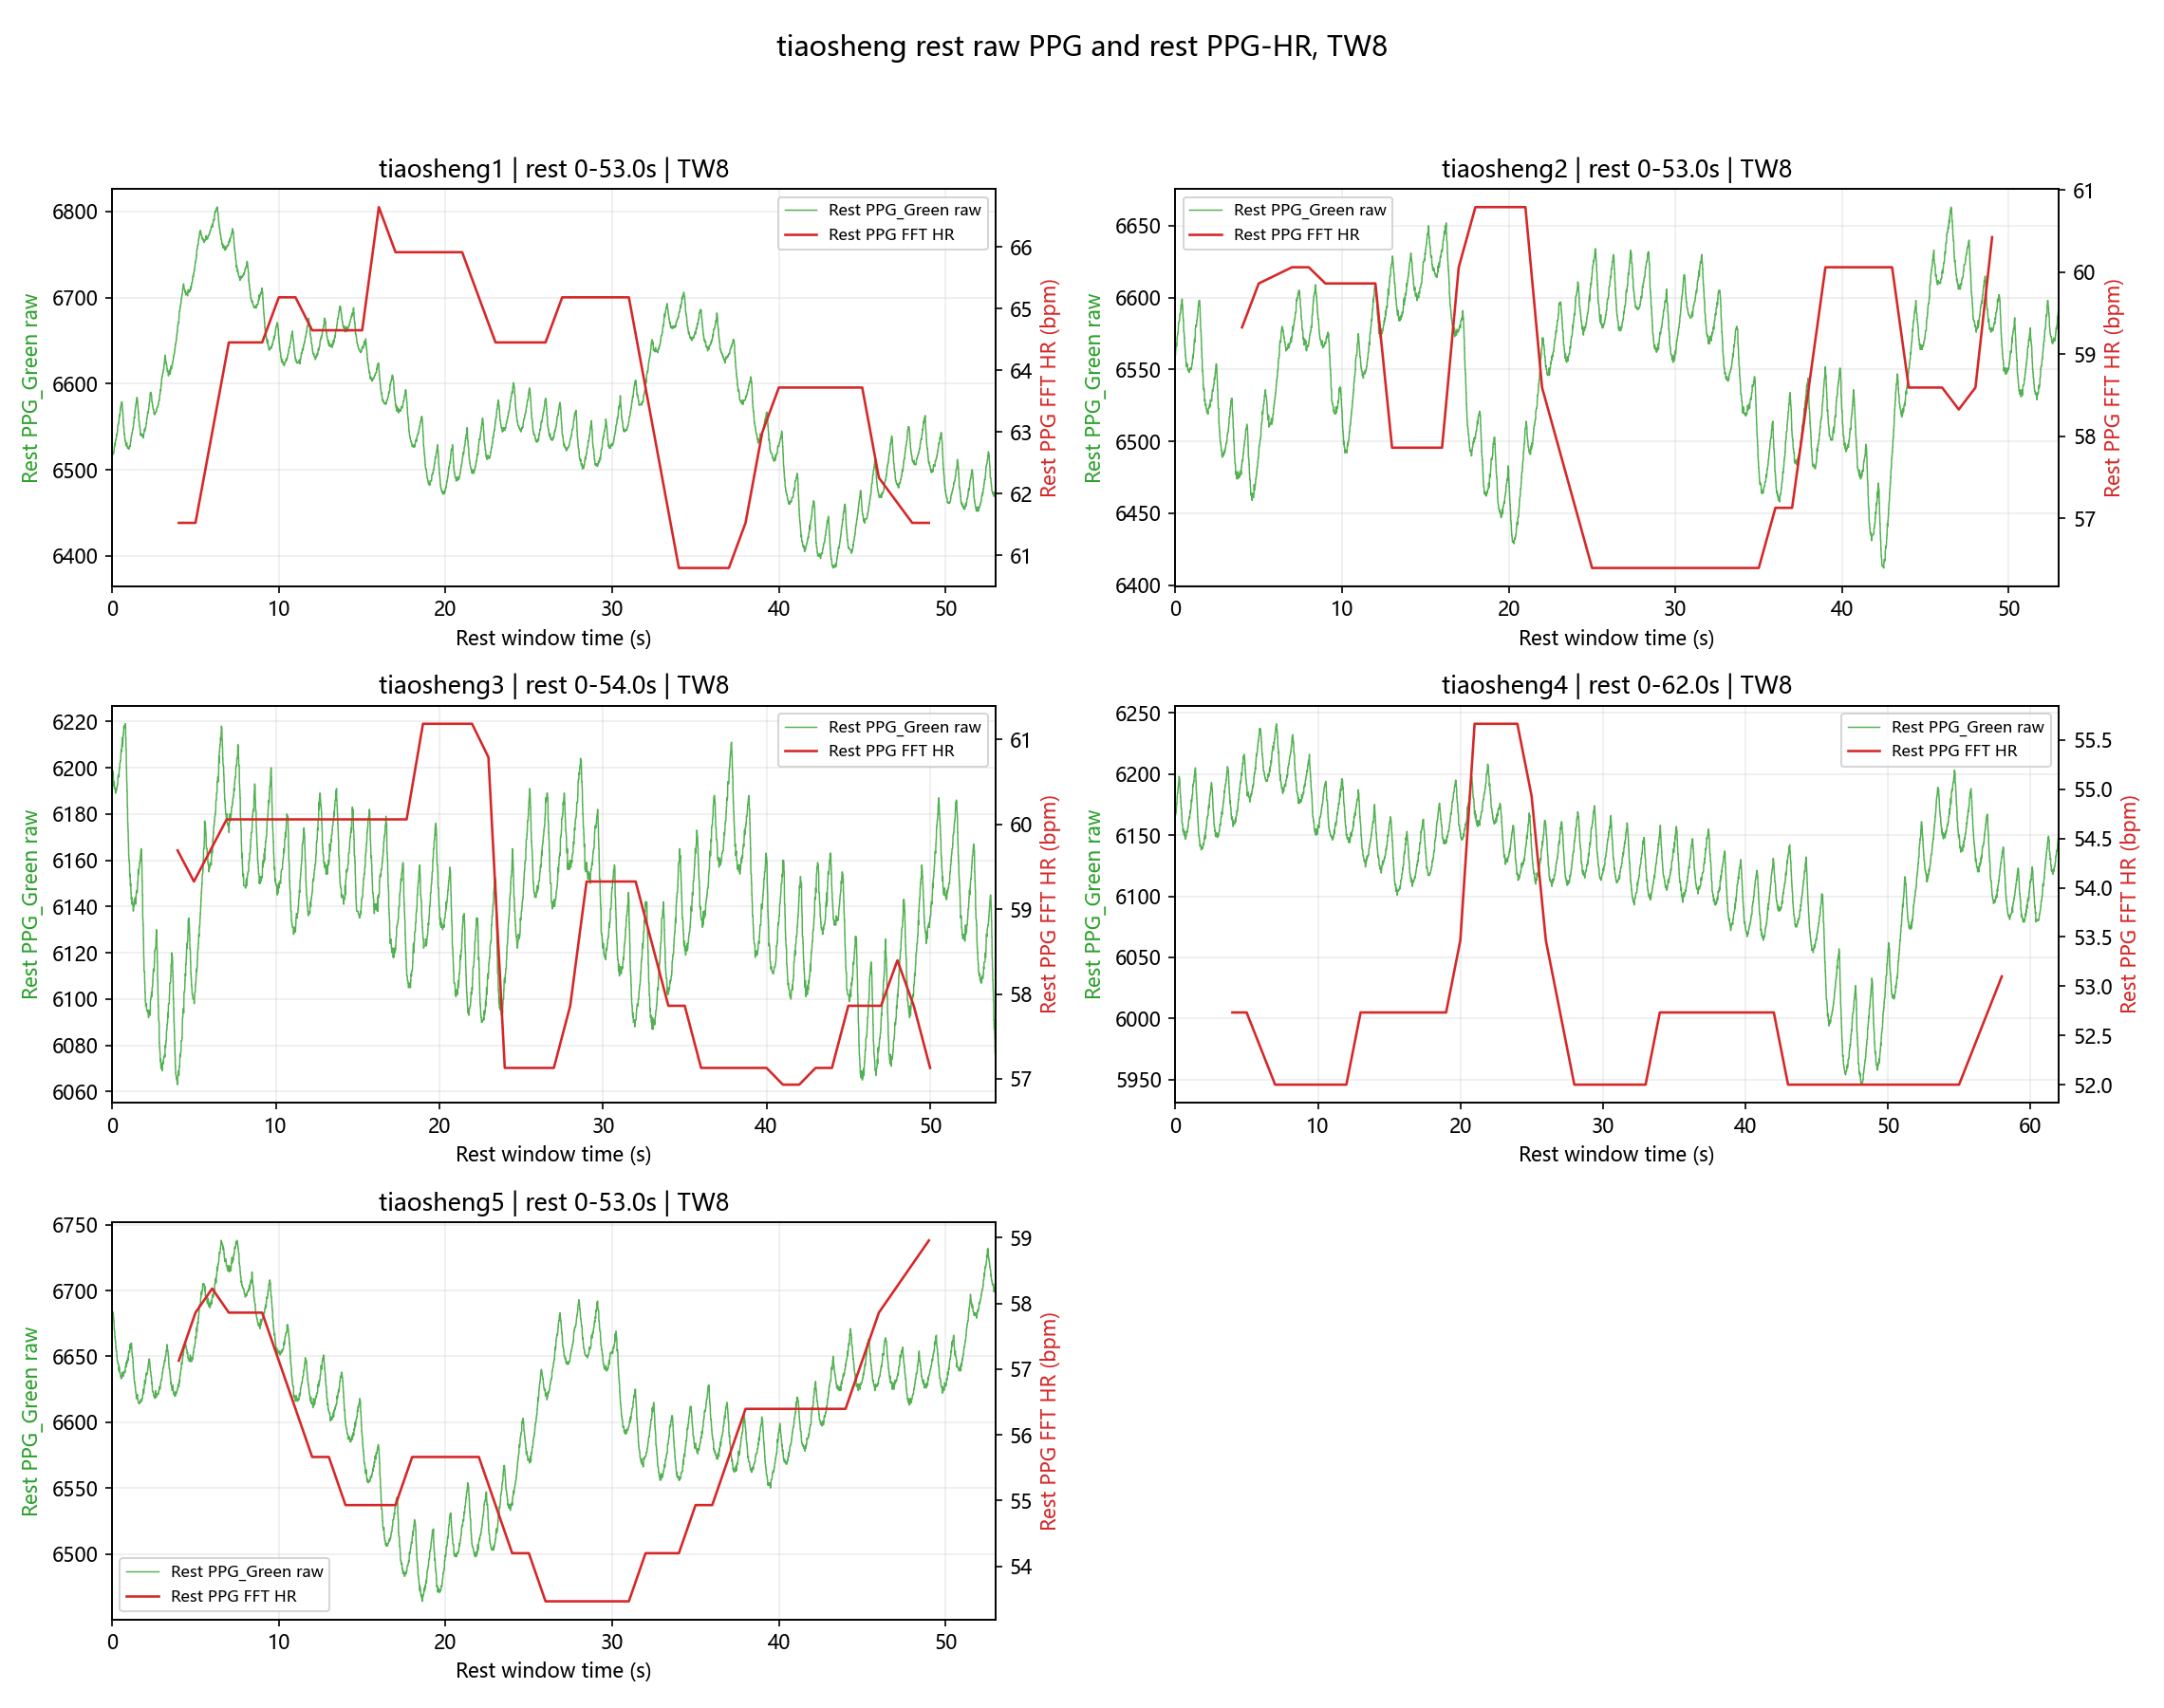

In [8]:
# ===== 小白导读：第 6 块静息段原始 PPG 与 PPG-HR 双 y 轴图 =====
# 作用：对每个运动类型绘制静息段原始 PPG 和由 PPG 估计出的 HR，观察静息信号质量。
# 输入：good_pairs、已加载或补加载的数据集、REST_HR_* 心率提取参数。
# 输出：raw_ppg_dual_axis_paths 字典，指向每个运动类型的一张双 y 轴 PNG。
# 数据流向：本单元只读数据和画图，不产生训练结果；它是第 3 块 Tdelay 诊断的辅助视角。
# 使用范例：如果第 3 块对齐图异常，运行本块检查静息段 PPG 波形是否漂移、断裂或周期不清。
# 关键参数：RAW_PPG_DUAL_AXIS_TW 控制 HR 提取窗口长度，默认与 ALIGNMENT_TW 一致。

RAW_PPG_DUAL_AXIS_DIR = OUTPUT_ROOT / "allfield"
RAW_PPG_DUAL_AXIS_TW = int(ALIGNMENT_TW)

raw_ppg_dual_axis_datasets = dict(
    globals().get("fullfield_ppg_hr_datasets", globals().get("alignment_diagnostic_datasets", {}))
)
for pair in good_pairs:
    if pair.motion_id in raw_ppg_dual_axis_datasets:
        continue
    try:
        raw_ppg_dual_axis_datasets[pair.motion_id] = load_and_preprocess_protocol(
            pair.sensor_csv,
            pair.ref_csv,
            fs_origin=FS_ORIGIN,
        )
    except Exception as exc:
        print(f"raw PPG dual-axis preprocessing failed: {pair.motion_id}: {exc}")

raw_ppg_dual_axis_paths = plot_raw_ppg_and_unaligned_hr_by_motion_type(
    pairs=good_pairs,
    datasets=raw_ppg_dual_axis_datasets,
    output_dir=RAW_PPG_DUAL_AXIS_DIR,
    fs_target=100,
    fs_origin=FS_ORIGIN,
    TW=RAW_PPG_DUAL_AXIS_TW,
    hr_band_hz=REST_HR_BAND_HZ,
    track_band_bpm=REST_HR_TRACK_BAND_BPM,
    slew_limit_bpm=REST_HR_SLEW_LIMIT_BPM,
    slew_step_bpm=REST_HR_SLEW_STEP_BPM,
    smooth_method=REST_HR_SMOOTH_METHOD,
    smooth_win=REST_HR_SMOOTH_WIN,
    peak_percent=REST_HR_PEAK_PERCENT,
    spec_penalty_enable=REST_HR_SPEC_PENALTY_ENABLE,
    spec_penalty_weight=REST_HR_SPEC_PENALTY_WEIGHT,
    spec_penalty_width_hz=REST_HR_SPEC_PENALTY_WIDTH_HZ,
)
print("raw_ppg_dual_axis_paths:", raw_ppg_dual_axis_paths)
for image_path in raw_ppg_dual_axis_paths.values():
    display(Image(filename=str(image_path)))


## 7. 训练单元 1：all_train 全样本拟合上限检查，注意 TW_F 的赋值与输入

`all_train` 用于观察全样本拟合上限。默认优先使用 `global` target scope；若当前枚举不支持 `global`，退回 `motion_post10` 并打印原因。


In [9]:
# ===== 小白导读：第 7 块 all_train 上限训练 =====
# 作用：用所有可用样本训练并测试同一批样本，观察流程在训练集上的拟合上限。
# 输入：第 1 块得到的 good_pairs、第 5 块 run_training_cell，以及本块设置的 scope/scheme/filter/预算。
# 输出：result_all_train；后续第 9/10/11/12 块默认会优先读取这个结果对象。
# 数据流向：训练结果写入 RUN_OUTPUT_DIR 下的新 run 目录，每个运动类型会有 Stage-6 CSV/JSON 文件。
# 使用范例：小规模检查保持 ACC3+lms+n_trials=1；正式实验可增加 n_trials/n_repeats 或扩展组合。
# 关键参数：ACTIVE_TARGET_SCOPES 控制评估窗口范围；CASCADE_TRAIN_BUDGETS 控制 Optuna 搜索预算。
TW_F=0
target_scope_values = [item.value for item in TargetScope]
# if "global" in target_scope_values:
#     ACTIVE_TARGET_SCOPES = ["global"]
# else:
#     ACTIVE_TARGET_SCOPES = ["motion_post10"]
#     print("TargetScope 不包含 global，保留 motion_post10 作为 all_train 上限检查。")
ACTIVE_TARGET_SCOPES = ["motion_recovery"]

ACTIVE_CASCADE_SCHEMES = ["HF2","HF2_CF2","ACC3"]
ACTIVE_ADAPTIVE_FILTERS = ["lms"]
CASCADE_TRAIN_BUDGETS = {
    "HF2": {"n_trials": 75, "n_repeats": 3},
    "HF2_CF2": {"n_trials": 75, "n_repeats": 3},
    "ACC3": {"n_trials": 75, "n_repeats": 3},
    }
OPTIMIZATION_OBJECTIVE = "aae"
DATA_SPLIT_MODE = "all_train"
VAL_GROUPS_PER_TYPE = 1
TEST_GROUPS_PER_TYPE = 1

result_all_train = run_training_cell(
    active_target_scopes=ACTIVE_TARGET_SCOPES,
    active_cascade_schemes=ACTIVE_CASCADE_SCHEMES,
    active_adaptive_filters=ACTIVE_ADAPTIVE_FILTERS,
    cascade_train_budgets=CASCADE_TRAIN_BUDGETS,
    optimization_objective=OPTIMIZATION_OBJECTIVE,
    data_split_mode=DATA_SPLIT_MODE,
    val_groups_per_type=VAL_GROUPS_PER_TYPE,
    test_groups_per_type=TEST_GROUPS_PER_TYPE,
    tw_f=TW_F,
    normalization_mode=NORMALIZATION_MODE,
    qc_policy=QC_POLICY,
)

for motion_type, motion_dir in result_all_train.motion_type_dirs.items():
    print("motion_type:", motion_type, motion_dir)
    for name in ["best_params_and_alignment.csv", "best_metrics.csv"]:
        path = motion_dir / name
        print(name, path.exists(), path)
        if path.exists():
            display(pd.read_csv(path).head())


OUTPUT_RUN_NAME: motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s
RUN_OUTPUT_DIR: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s
trial_param_overrides: {'TW_F': 0.0, 'normalization_mode': 'minmax', 'qc_policy': 'fallback_baseline', 'delay_estimation_mode': 'envelope', 'Alignment_TW': 8.0, 'Alignment_Step': 1.0, 'Rest_HR_Band_BPM': (40.0, 180.0), 'Rest_HR_Track_Band_BPM': 30.0, 'Rest_HR_Slew_Limit_BPM': 4.0, 'Rest_HR_Slew_Step_BPM': 2.0, 'Rest_HR_Smooth_Method': 'median', 'Rest_HR_Smooth_Win': 7, 'Rest_HR_Peak_Percent': 0.3, 'Rest_HR_Spec_Penalty_Enable': True, 'Rest_HR_Spec_Penalty_Weight': 0.2, 'Rest_HR_Spec_Penalty_Width_Hz': 0.2, 'Rest_Alignment_Score_Mode': 'aae', 'Enable_Time_Bias_After': True, 'Time_Bias_After_Range_S': (-5.0, 5.0), 'Time_Bias_After_Step_S': 1.0, 'Time_Bias_After_Mode': 'posthoc_oracle_alignment', 'Recovery_Grace_S': 15.0, 'Recovery_Diff_Bpm': 150.0, 'Recovery_Cross_D

,motion_type,split,mode,target_scope,objective_mode,cascade_scheme,adaptive_filter,adaptive_data_type,TW,TW_F,...,alignment_score_mode,pre_align_metric_json,no_posthoc_final_aae_bpm,no_posthoc_final_acc_pct,posthoc_final_aae_bpm,posthoc_final_acc_pct,baseline_aae_bpm,baseline_acc_pct,adaptive_aae_bpm,adaptive_acc_pct
0,tiaosheng,fold_0,all_train,motion_recovery,aae,HF2,lms,HF2,8.0,0.0,...,aae,{},6.073589,56.844850,5.540633,59.843546,15.580663,41.329857,6.009523,56.714472
1,tiaosheng,fold_0,all_train,motion_recovery,aae,HF2_CF2,lms,HF2_CF2,8.0,0.0,...,aae,{},5.989725,55.366492,5.315572,64.136126,11.403864,39.397906,5.949187,55.366492
2,tiaosheng,fold_0,all_train,motion_recovery,aae,ACC3,lms,ACC3,8.0,0.0,...,aae,{},5.948251,54.319372,5.183416,63.219895,11.084381,38.874346,5.885126,54.319372


best_metrics.csv True D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s\motion_types\tiaosheng\best_metrics.csv


,motion_type,split,mode,target_scope,filter_type,adaptive_data_type,TW,TW_F,baseline_aae_bpm,adaptive_aae_bpm,...,posthoc_baseline_aae_bpm,posthoc_adaptive_aae_bpm,posthoc_final_aae_bpm,posthoc_baseline_acc_pct,posthoc_adaptive_acc_pct,posthoc_final_acc_pct,n_windows,n_valid_windows,n_qc_fallback,n_recovery_fallback
0,tiaosheng,fold_0,all_train,motion_recovery,lms,HF2,8.0,0.0,15.580663,6.009523,...,15.243560,5.460921,5.540633,44.719687,60.104302,59.843546,767,767,0,0
1,tiaosheng,fold_0,all_train,motion_recovery,lms,HF2_CF2,8.0,0.0,11.403864,5.949187,...,11.141879,5.271539,5.315572,45.157068,64.005236,64.136126,764,764,0,0
2,tiaosheng,fold_0,all_train,motion_recovery,lms,ACC3,8.0,0.0,11.084381,5.885126,...,10.751433,5.120291,5.183416,44.764398,63.219895,63.219895,764,764,0,0


## 8. 训练单元 2：完整 84 模式连通性检查

默认关闭。若开启，该单元运行 3 个 target scope x 7 个 cascade scheme x 4 个 adaptive filter，共 84 模式。

说明：adaptive filter 包含 `lms` / `volterra` / `rff_lms` / `klms`；如果需要纳入 `global/all`，组合会变为 4 x 7 x 4 = 112 模式，应另开全局连通性测试，不要混淆“84 模式”定义。


In [ ]:
# ===== 小白导读：第 8 块 84 模式连通性检查 =====
# 作用：可选地跑 3 个 target scope x 7 个 cascade scheme x 4 个滤波器，用于检查完整组合是否能连通。
# 输入：RUN_FULL_84_MODE_TEST 开关，以及本块列出的 target_scopes/cascade_schemes/adaptive_filters。
# 输出：开启时生成 result_full_84；关闭时只打印跳过提示，不会耗时训练。
# 数据流向：若运行成功，第 9/10/11/12 块可以改用 result_full_84 的 output_root 做检查和回放。
# 使用范例：默认 False；只有确认第 7 块小规模训练可跑通后，再手动改 True。
# 关键提醒：这里定义的是 84 模式；如果加入 global，就变成 112 模式，应单独说明，避免结果混淆。

RUN_FULL_84_MODE_TEST = False

if RUN_FULL_84_MODE_TEST:
    ACTIVE_TARGET_SCOPES = ["motion_only", "motion_recovery", "motion_post10"]
    ACTIVE_CASCADE_SCHEMES = ["ACC3", "HF2", "CF2", "HF2_CF2", "CF2_HF2", "ACC3_HF2", "HF2_ACC3"]
    ACTIVE_ADAPTIVE_FILTERS = ["lms", "volterra", "rff_lms", "klms"]
    CASCADE_TRAIN_BUDGETS = make_budgets(ACTIVE_CASCADE_SCHEMES, n_trials=1, n_repeats=1)
    OPTIMIZATION_OBJECTIVE = "accuracy"
    DATA_SPLIT_MODE = "split"
    VAL_GROUPS_PER_TYPE = 1
    TEST_GROUPS_PER_TYPE = 1
    result_full_84 = run_training_cell(
        active_target_scopes=ACTIVE_TARGET_SCOPES,
        active_cascade_schemes=ACTIVE_CASCADE_SCHEMES,
        active_adaptive_filters=ACTIVE_ADAPTIVE_FILTERS,
        cascade_train_budgets=CASCADE_TRAIN_BUDGETS,
        optimization_objective=OPTIMIZATION_OBJECTIVE,
        data_split_mode=DATA_SPLIT_MODE,
        val_groups_per_type=VAL_GROUPS_PER_TYPE,
        test_groups_per_type=TEST_GROUPS_PER_TYPE,
        tw_f=TW_F,
        normalization_mode=NORMALIZATION_MODE,
        qc_policy=QC_POLICY,
    )
else:
    print("RUN_FULL_84_MODE_TEST=False，已跳过完整 84 模式测试。")


## 9. 输出检查

检查新 Stage-6 记录结构：`best_params_and_alignment.csv`、`best_metrics.csv`、`motion_frequency_and_params.csv`、`full_report.json`。


In [10]:
# ===== 小白导读：第 9 块 Stage-6 输出检查 =====
# 作用：检查每个运动类型目录中是否存在新的 Stage-6 记录文件，并展示关键列和 fusion 分布。
# 输入：RESULT_TO_CHECK，通常来自 result_all_train 或 result_full_84；也可以手动指定已有结果对象。
# 输出：每个 motion_type 的 best_params_and_alignment.csv、best_metrics.csv、motion_frequency_and_params.csv 和 full_report.json 摘要。
# 数据流向：第 10/11/12 块会继续读取这些 Stage-6 文件进行 replay、窗口诊断和跨运动汇总。
# 使用范例：如果第 10 块找不到 best_params_and_alignment.csv，先回到本块看 motion_type_dirs 是否正确。
# 关键列：TW_F、normalization_mode、best_tdelay_s、time_bias_after_s、n_qc_fallback 等用于确认流程是否和固定参数一致。

RESULT_TO_CHECK = globals().get(
    "result_full_84",
    globals().get("result_full_63", globals().get("result_leave_one_group_out", globals().get("result_all_train", globals().get("result_split", None)))),
)

STAGE6_FILES = [
    "best_params_and_alignment.csv",
    "best_metrics.csv",
    "motion_frequency_and_params.csv",
    "full_report.json",
]
STAGE6_REQUIRED_COLUMNS = [
    "final_aae_bpm",
    "final_acc_pct",
    "posthoc_final_aae_bpm",
    "posthoc_final_acc_pct",
    "TW_F",
    "normalization_mode",
    "best_tdelay_s",
    "time_bias_after_s",
    "n_windows",
    "n_valid_windows",
    "n_qc_fallback",
    "n_recovery_fallback",
]

if RESULT_TO_CHECK is None:
    print("没有可检查的训练结果，请先运行第 7 单元或手动设置 RESULT_TO_CHECK。")
else:
    print("output_root:", RESULT_TO_CHECK.output_root)
    print("qc_tables:", RESULT_TO_CHECK.qc_tables)
    print("batch_summary:", RESULT_TO_CHECK.batch_summary_csv)
    print("motion_type_dirs:", RESULT_TO_CHECK.motion_type_dirs)

    for motion_type, motion_dir in RESULT_TO_CHECK.motion_type_dirs.items():
        print("\nmotion_type:", motion_type, motion_dir)
        observed_columns = set()
        for name in STAGE6_FILES:
            path = motion_dir / name
            print(name, path.exists(), path)
            if not path.exists():
                continue
            if path.suffix.lower() == ".csv":
                df = pd.read_csv(path)
                observed_columns.update(df.columns)
                display(df.head())
            elif path.name == "full_report.json":
                report = json.loads(path.read_text(encoding="utf-8"))
                print("full_report keys:", sorted(report.keys()))
                distribution = report.get("fusion_source_distribution", {})
                print("fusion_source_distribution:", distribution)
                if distribution:
                    display(pd.DataFrame([distribution]))

        missing_columns = [column for column in STAGE6_REQUIRED_COLUMNS if column not in observed_columns]
        if missing_columns:
            print("Stage-6 记录缺少列:", missing_columns)
        else:
            print("Stage-6 必需列检查 OK")


output_root: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s
qc_tables: {'good': WindowsPath('D:/data/PPG_HeartRate/Algorithm/Algorithm/PPGtoHR_notebook/outputs/motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s/qc/good_samples.csv'), 'bad': WindowsPath('D:/data/PPG_HeartRate/Algorithm/Algorithm/PPGtoHR_notebook/outputs/motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s/qc/bad_samples.csv'), 'unpaired': WindowsPath('D:/data/PPG_HeartRate/Algorithm/Algorithm/PPGtoHR_notebook/outputs/motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s/qc/unpaired_samples.csv'), 'summary': WindowsPath('D:/data/PPG_HeartRate/Algorithm/Algorithm/PPGtoHR_notebook/outputs/motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s/qc/qc_summary.csv'), 'motion_type_samples': WindowsPath('D:/data/PPG_HeartRate/Algorithm/Algorithm/PPGtoHR_notebook/outputs/motion_recovery__HF2-HF2_CF2-ACC3__lms_

,motion_type,split,mode,target_scope,objective_mode,cascade_scheme,adaptive_filter,adaptive_data_type,TW,TW_F,...,alignment_score_mode,pre_align_metric_json,no_posthoc_final_aae_bpm,no_posthoc_final_acc_pct,posthoc_final_aae_bpm,posthoc_final_acc_pct,baseline_aae_bpm,baseline_acc_pct,adaptive_aae_bpm,adaptive_acc_pct
0,tiaosheng,fold_0,all_train,motion_recovery,aae,HF2,lms,HF2,8.0,0.0,...,aae,{},6.073589,56.844850,5.540633,59.843546,15.580663,41.329857,6.009523,56.714472
1,tiaosheng,fold_0,all_train,motion_recovery,aae,HF2_CF2,lms,HF2_CF2,8.0,0.0,...,aae,{},5.989725,55.366492,5.315572,64.136126,11.403864,39.397906,5.949187,55.366492
2,tiaosheng,fold_0,all_train,motion_recovery,aae,ACC3,lms,ACC3,8.0,0.0,...,aae,{},5.948251,54.319372,5.183416,63.219895,11.084381,38.874346,5.885126,54.319372


best_metrics.csv True D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s\motion_types\tiaosheng\best_metrics.csv


,motion_type,split,mode,target_scope,filter_type,adaptive_data_type,TW,TW_F,baseline_aae_bpm,adaptive_aae_bpm,...,posthoc_baseline_aae_bpm,posthoc_adaptive_aae_bpm,posthoc_final_aae_bpm,posthoc_baseline_acc_pct,posthoc_adaptive_acc_pct,posthoc_final_acc_pct,n_windows,n_valid_windows,n_qc_fallback,n_recovery_fallback
0,tiaosheng,fold_0,all_train,motion_recovery,lms,HF2,8.0,0.0,15.580663,6.009523,...,15.243560,5.460921,5.540633,44.719687,60.104302,59.843546,767,767,0,0
1,tiaosheng,fold_0,all_train,motion_recovery,lms,HF2_CF2,8.0,0.0,11.403864,5.949187,...,11.141879,5.271539,5.315572,45.157068,64.005236,64.136126,764,764,0,0
2,tiaosheng,fold_0,all_train,motion_recovery,lms,ACC3,8.0,0.0,11.084381,5.885126,...,10.751433,5.120291,5.183416,44.764398,63.219895,63.219895,764,764,0,0


motion_frequency_and_params.csv True D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s\motion_types\tiaosheng\motion_frequency_and_params.csv


,motion_type,split,mode,motion_frequency_hz,penalty_ref_channel,cascade_scheme,adaptive_filter,adaptive_data_type,TW,TW_F,max_order,M_base,C_scale,K_max,Spec_Penalty_Width,Spec_Penalty_Weight,reference_channel_ranking_summary
0,tiaosheng,fold_0,all_train,NaN,NaN,HF2,lms,HF2,8.0,0.0,16,2,1.2,20,0.2,0.4,NaN
1,tiaosheng,fold_0,all_train,NaN,NaN,HF2_CF2,lms,HF2_CF2,8.0,0.0,12,2,1.2,16,0.2,0.2,NaN
2,tiaosheng,fold_0,all_train,NaN,NaN,ACC3,lms,ACC3,8.0,0.0,8,2,1.5,30,0.2,0.1,NaN


full_report.json True D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s\motion_types\tiaosheng\full_report.json
full_report keys: ['alignment', 'best_trials', 'config', 'failed_samples', 'fusion_source_distribution', 'git_commit_hash', 'motion_type', 'posthoc_time_bias_after', 'qc_summary', 'run_command', 'search_space', 'split_metrics', 'version_info']
fusion_source_distribution: {}
Stage-6 必需列检查 OK


## 10. 对单个文件的 best_params HR 曲线进行重绘

使用 Stage-7 `replay_best_record_hr_curves` 从 `best_params_and_alignment.csv` 恢复参数并重绘单文件 HR 曲线。旧 `best_params_lms.csv` 接口不再作为默认入口。


Stage-7 selector source: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\motion_recovery__HF2-HF2_CF2-ACC3__lms__aae__all_train__TW_F0s\motion_types\tiaosheng\best_params_and_alignment.csv


,motion_type,split,mode,target_scope,objective_mode,cascade_scheme,adaptive_filter,adaptive_data_type,TW,TW_F,...,alignment_score_mode,pre_align_metric_json,no_posthoc_final_aae_bpm,no_posthoc_final_acc_pct,posthoc_final_aae_bpm,posthoc_final_acc_pct,baseline_aae_bpm,baseline_acc_pct,adaptive_aae_bpm,adaptive_acc_pct
0,tiaosheng,fold_0,all_train,motion_recovery,aae,HF2,lms,HF2,8.0,0.0,...,aae,{},6.073589,56.84485,5.540633,59.843546,15.580663,41.329857,6.009523,56.714472


replay CSV: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\manual_replay\replay_tiaosheng_lms_HF2_TW_F0s_motion_recovery.csv
replay PNG: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\manual_replay\replay_tiaosheng_lms_HF2_TW_F0s_motion_recovery.png


,time_s,reference_hr_bpm,baseline_hr_bpm,adaptive_hr_bpm,final_hr_bpm,final_source,segment_label,fusion_reason
0,4.0,56.000000,52.734375,52.734375,52.734375,baseline_fft,rest,rest_segment_baseline
1,5.0,56.000000,54.199219,54.199219,54.199219,baseline_fft,rest,rest_segment_baseline
2,6.0,56.788809,54.931641,54.931641,54.931641,baseline_fft,rest,rest_segment_baseline
3,7.0,57.000000,54.931641,54.931641,54.931641,baseline_fft,rest,rest_segment_baseline
4,8.0,57.000000,55.664062,55.664062,55.664062,baseline_fft,rest,rest_segment_baseline


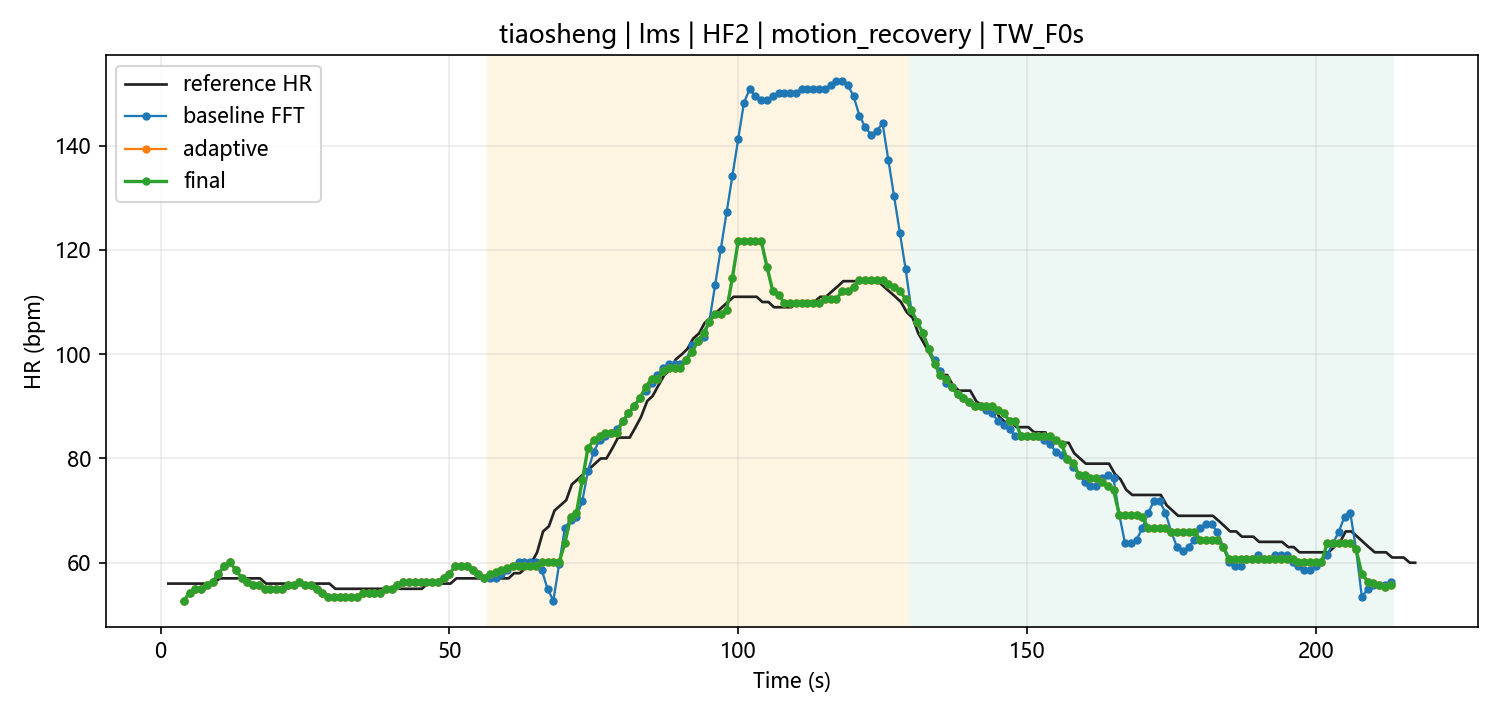

In [14]:
# ===== 小白导读：第 10 块 Stage-7 单文件 replay =====
# 作用：读取 Stage-6 的 best_params_and_alignment.csv，恢复最优参数，对单个 CSV 重新生成 HR 曲线。
# 输入：REPLAY_SIGNAL_CSV/REPLAY_REF_CSV 指定样本；REPLAY_RESULTS_ROOT 指向已有训练结果根目录。
# 输出：REPLAY_CSV 保存窗口级 HR 数值；REPLAY_PNG 保存参考、baseline、adaptive、final HR 曲线图。
# 数据流向：第 11 块会读取 REPLAY_CSV 或复用本块选择的 split/mode/scope/filter/scheme 参数。
# 使用范例：想换成 kaihe1，就把 REPLAY_SIGNAL_CSV/REPLAY_REF_CSV 和 REPLAY_MOTION_TYPE 改成对应文件与运动类型。
# 关键参数：REPLAY_TARGET_SCOPE、REPLAY_ADAPTIVE_FILTER、REPLAY_CASCADE_SCHEME 必须和 Stage-6 记录中存在的组合匹配。

RUN_STAGE7_REPLAY = True

REPLAY_SIGNAL_CSV = TESTDATA_DIR / "multi_tiaosheng5.csv"
REPLAY_REF_CSV = TESTDATA_DIR / "multi_tiaosheng5_HR_ref.csv"
REPLAY_RESULTS_ROOT = Path(getattr(globals().get("RESULT_TO_CHECK", None), "output_root", RUN_OUTPUT_DIR))
REPLAY_OUTPUT_DIR = OUTPUT_ROOT / "manual_replay"
REPLAY_MOTION_TYPE = "tiaosheng"
REPLAY_TARGET_SCOPE = ACTIVE_TARGET_SCOPES[0] if ACTIVE_TARGET_SCOPES else "global"
REPLAY_ADAPTIVE_FILTER = "lms"
REPLAY_CASCADE_SCHEME = "HF2+CF2"
REPLAY_ADAPTIVE_DATA_TYPE = ""
REPLAY_TW_F = TW_F

# 如需强制选择特定 split/mode，可在这里填入字符串；留空时自动读取 Stage-6 记录第一条匹配行。
REPLAY_MANUAL_SPLIT = ""
REPLAY_MANUAL_MODE = ""


def _stage6_motion_dir(results_root, motion_type):
    root = Path(results_root)
    candidates = [root / "motion_types" / motion_type, root / motion_type, root]
    for item in candidates:
        if (item / "best_params_and_alignment.csv").exists():
            return item
    return candidates[0]


def _select_stage6_selector_row(
    *,
    results_root,
    motion_type,
    target_scope,
    adaptive_filter,
    cascade_scheme,
    adaptive_data_type="",
    tw_f=None,
):
    motion_dir = _stage6_motion_dir(results_root, motion_type)
    params_path = motion_dir / "best_params_and_alignment.csv"
    if not params_path.exists():
        raise FileNotFoundError(params_path)
    df = pd.read_csv(params_path)
    candidates = df.copy()
    filters = {
        "motion_type": motion_type,
        "target_scope": target_scope,
        "adaptive_filter": adaptive_filter,
        "cascade_scheme": cascade_scheme,
        "adaptive_data_type": adaptive_data_type,
    }
    for column, expected in filters.items():
        if not expected or column not in candidates.columns:
            continue
        narrowed = candidates[candidates[column].astype(str) == str(expected)]
        if not narrowed.empty:
            candidates = narrowed
    if tw_f is not None and "TW_F" in candidates.columns:
        values = pd.to_numeric(candidates["TW_F"], errors="coerce")
        narrowed = candidates[np.isclose(values.astype(float), float(tw_f), equal_nan=False)]
        if not narrowed.empty:
            candidates = narrowed
    if candidates.empty:
        raise ValueError(f"未找到匹配 Stage-6 参数行: {params_path}")
    return candidates.iloc[0], params_path


if RUN_STAGE7_REPLAY:
    try:
        selector_row, selector_path = _select_stage6_selector_row(
            results_root=REPLAY_RESULTS_ROOT,
            motion_type=REPLAY_MOTION_TYPE,
            target_scope=REPLAY_TARGET_SCOPE,
            adaptive_filter=REPLAY_ADAPTIVE_FILTER,
            cascade_scheme=REPLAY_CASCADE_SCHEME,
            adaptive_data_type=REPLAY_ADAPTIVE_DATA_TYPE,
            tw_f=REPLAY_TW_F,
        )
        REPLAY_SPLIT = REPLAY_MANUAL_SPLIT or str(selector_row.get("split", ""))
        REPLAY_MODE = REPLAY_MANUAL_MODE or str(selector_row.get("mode", ""))
        REPLAY_TARGET_SCOPE = str(selector_row.get("target_scope", REPLAY_TARGET_SCOPE))
        REPLAY_ADAPTIVE_FILTER = str(selector_row.get("adaptive_filter", REPLAY_ADAPTIVE_FILTER))
        REPLAY_ADAPTIVE_DATA_TYPE = str(selector_row.get("adaptive_data_type", REPLAY_ADAPTIVE_DATA_TYPE))
        REPLAY_CASCADE_SCHEME = str(selector_row.get("cascade_scheme", REPLAY_CASCADE_SCHEME))
        print("Stage-7 selector source:", selector_path)
        display(pd.DataFrame([selector_row.to_dict()]))

        replay_paths = replay_best_record_hr_curves(
            signal_csv=REPLAY_SIGNAL_CSV,
            ref_csv=REPLAY_REF_CSV,
            results_root=REPLAY_RESULTS_ROOT,
            output_dir=REPLAY_OUTPUT_DIR,
            motion_type=REPLAY_MOTION_TYPE,
            split=REPLAY_SPLIT,
            mode=REPLAY_MODE,
            target_scope=REPLAY_TARGET_SCOPE,
            adaptive_filter=REPLAY_ADAPTIVE_FILTER,
            adaptive_data_type=REPLAY_ADAPTIVE_DATA_TYPE,
            cascade_scheme=REPLAY_CASCADE_SCHEME,
            TW_F=REPLAY_TW_F,
            fs_origin=FS_ORIGIN,
        )
        REPLAY_CSV = replay_paths["csv"]
        REPLAY_PNG = replay_paths["plot"]
        print("replay CSV:", REPLAY_CSV)
        print("replay PNG:", REPLAY_PNG)
        display(pd.read_csv(REPLAY_CSV).head())
        display(Image(filename=str(REPLAY_PNG)))
    except Exception as exc:
        print("Stage-7 replay 未执行:", exc)
else:
    print("RUN_STAGE7_REPLAY=False，已跳过 Stage-7 replay。")


## 11. 对单个文件的窗口级波形与频谱诊断图重绘

使用 Stage-8 `plot_window_diagnostics_from_records` 重绘单个窗口的原始/滤波波形和频谱诊断图，并展示级联 stage 摘要。

这里的 `stage 1`、`stage 2` 等表示同一窗口内的级联自适应滤波步骤：每一级会选择一个参考通道，例如 `ACC3` 可能依次使用 `accx/accy/accz` 中排序靠前的通道；`output_signal` 是 PPG 经过该级滤波后的中间波形。它们不是 HR 曲线，也不是新的 Optuna 搜索参数，而是帮助理解“PPG 是怎样一步步被参考通道滤掉运动伪迹”的窗口级证据。

本节生成两张图：波形图使用双 y 轴，左 y 轴显示原始 PPG 和每个 stage 中间波形，右 y 轴显示最终自适应滤波后的波形；频谱图只截取绿色 `FFT window` 内的数据，绘制三条归一化 FFT 幅频谱曲线：原始 PPG、自适应滤波后 PPG、自适应滤波加运动频谱惩罚后的 PPG。频谱图中的 motion 线来自当前 FFT 窗内的伪影参考通道主峰；心率线不是 `final_hr_bpm`，而是“频谱惩罚后、上一窗 HR 约束和平滑之前”的当前窗候选 HR。


aligned_fft_start_s: 115
waveform: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\window_diagnostics\window_waveform_tiaosheng_lms_HF2_TW_F0s_motion_recovery_start115s.png
spectrum: D:\data\PPG_HeartRate\Algorithm\Algorithm\PPGtoHR_notebook\outputs\window_diagnostics\window_spectrum_tiaosheng_lms_HF2_TW_F0s_motion_recovery_start115s.png


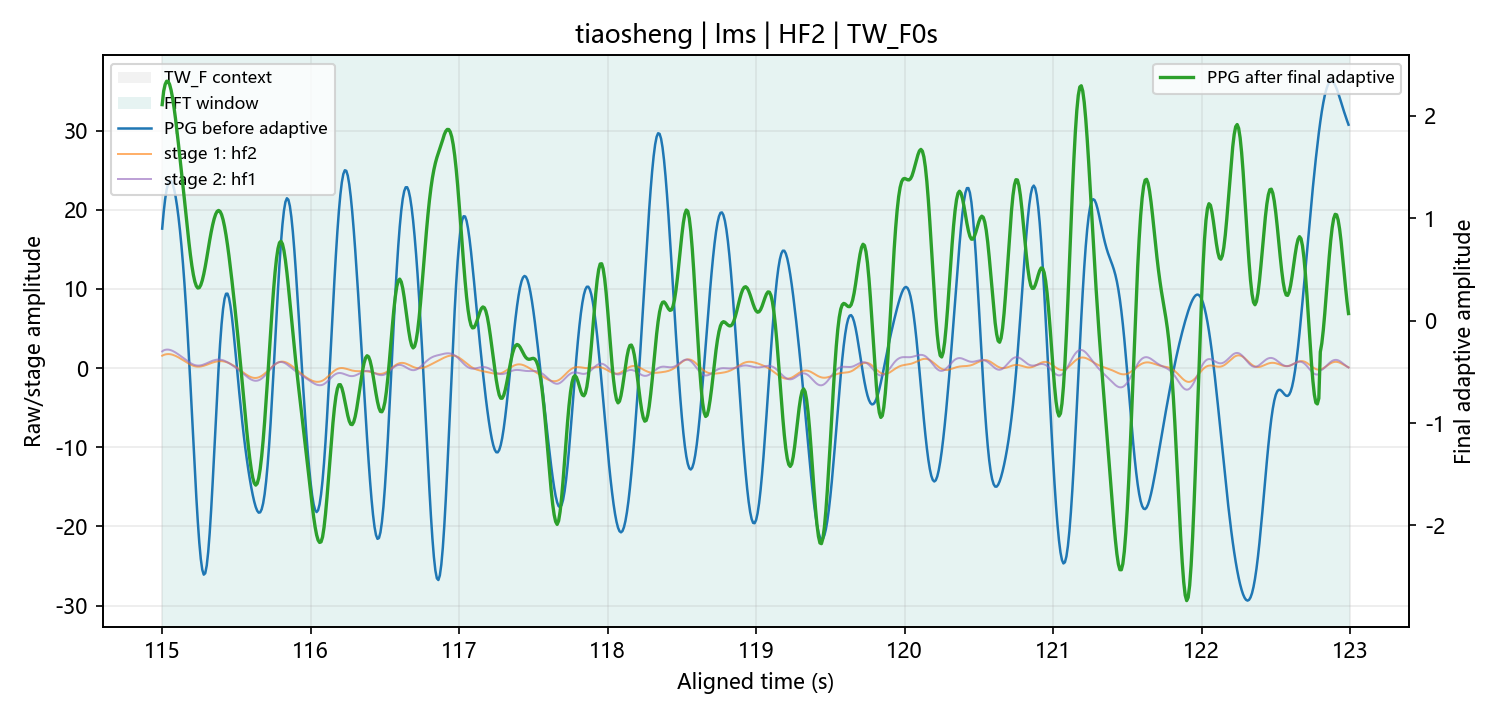

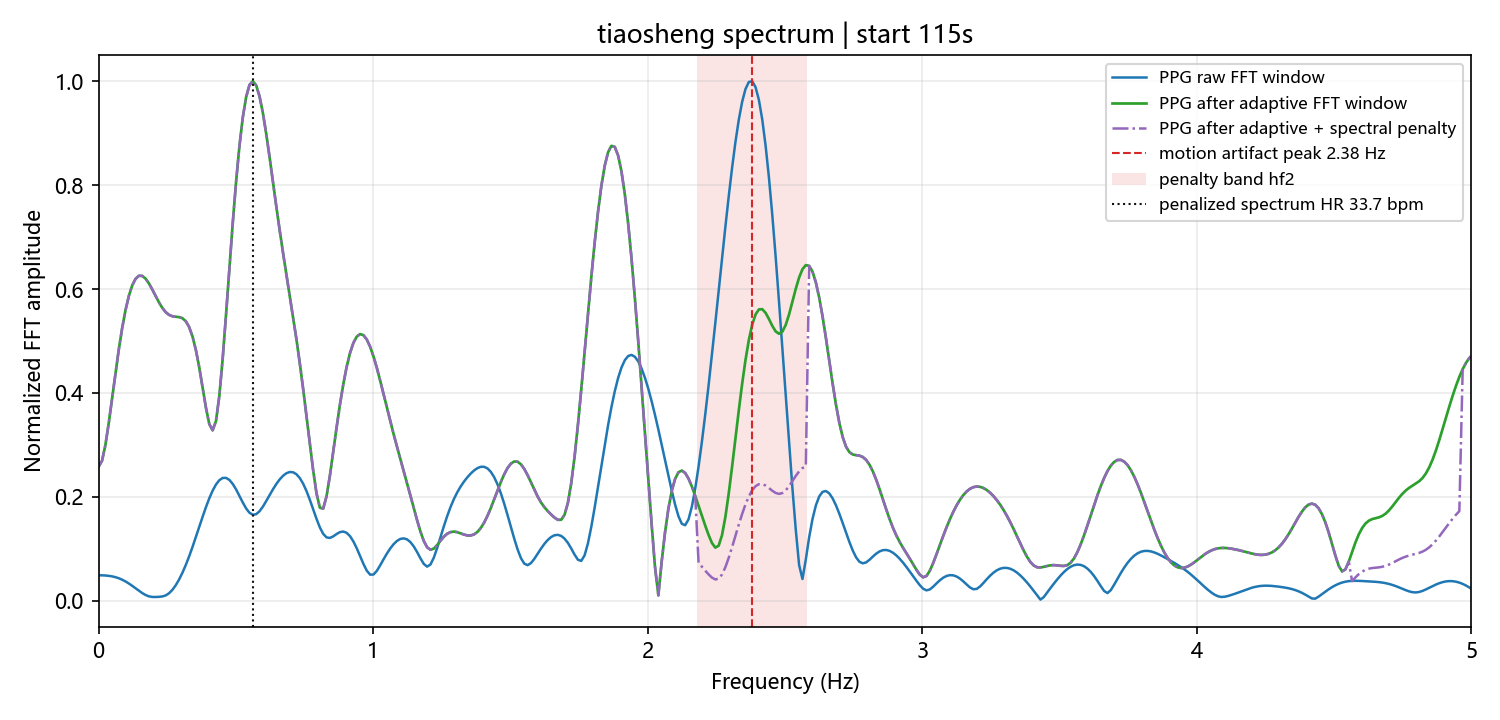

当前 FFT 窗频谱标注信息:


,motion_artifact_peak_hz,penalized_spectrum_hr_bpm
0,2.380371,33.691406


本次 Stage-8 replay 使用的最佳贝叶斯/Optuna 参数:


,parameter,value
0,Fs_Target,100
1,TW,8
2,TW_F,0.0
3,normalization_mode,minmax
4,Kstop,0.3
5,max_order,16
6,M_base,2
7,C_scale,1.2
8,K_max,20
9,Spec_Penalty_Width,0.2


对应 Stage-6 best_params_and_alignment.csv 记录:


,motion_type,split,mode,target_scope,objective_mode,cascade_scheme,adaptive_filter,adaptive_data_type,TW,TW_F,...,alignment_score_mode,pre_align_metric_json,no_posthoc_final_aae_bpm,no_posthoc_final_acc_pct,posthoc_final_aae_bpm,posthoc_final_acc_pct,baseline_aae_bpm,baseline_acc_pct,adaptive_aae_bpm,adaptive_acc_pct
0,tiaosheng,fold_0,all_train,motion_recovery,aae,HF2,lms,HF2,8.0,0.0,...,aae,{},6.073589,56.84485,5.540633,59.843546,15.580663,41.329857,6.009523,56.714472


stages non-empty: True stage_count: 2
stage 样本数采用 Fs_Target 坐标: Fs_Target=100 Hz, TW_F=0s, TW=8s,  理论自适应输入点数约=800


,stage,channel,M,K,mu,penalty_ref_channel,Fs_Target_Hz,output_len,output_len_s,adaptive_input_samples,adaptive_input_s,fft_input_samples,fft_input_s,fft_offset_samples,fft_offset_s,reference_channel_ranking
0,1,hf2,2,0,0.005004,hf2,100.0,800,8.0,800,8.0,800,8.0,0,0.0,"{""HF"": [""hf2"", ""hf1""], ""CF"": [""cf2"", ""cf1""], ""..."
1,2,hf1,2,20,0.008436,hf2,100.0,800,8.0,800,8.0,800,8.0,0,0.0,"{""HF"": [""hf2"", ""hf1""], ""CF"": [""cf2"", ""cf1""], ""..."


In [16]:
# ===== 小白导读：第 11 块 Stage-8 窗口级波形与频谱诊断 =====
# 作用：选取单个 aligned FFT 窗口，重画原始 PPG、级联每级输出、最终自适应滤波输出和 FFT 窗内三条归一化频谱。
# 输入：第 10 块的 REPLAY_* 选择器、REPLAY_RESULTS_ROOT 中的 Stage-6 文件、以及 aligned_fft_start_s 窗口起点。
# 输出：
#   1. diagnostic_paths['waveform']：双 y 轴波形图；
#   2. diagnostic_paths['spectrum']：只基于 FFT window 的归一化频谱图；
#   3. diagnostic_paths['stages']：每级滤波元数据；
#   4. diagnostic_paths['best_params']：本次 replay 使用的最佳贝叶斯/Optuna 参数；
#   5. diagnostic_paths['spectrum_info']：当前 FFT 窗内 motion 峰和惩罚后候选 HR。
# 数据流向：plot_window_diagnostics_from_records 会读取 Stage-6 参数，重新跑一次单样本 run_protocol_trial，但不会重新训练 Optuna。
# 使用范例：如果想诊断 80 秒处的窗口，把 MANUAL_ALIGNED_FFT_START_S 设为 80；如果想自动取 replay 第一窗，设为 None。
# stage 含义：stage 1/2/... 是级联滤波中的第 1/2/... 个自适应滤波步骤输出，例如 ACC3 会依次选择 ACC 通道；
#             每个 stage 保存 channel、M、K、mu、penalty_ref_channel 和 reference_channel_ranking 等参数。
#             它们不是新的搜索参数表，也不是最终 HR；它们是同一个窗口内 PPG 波形经过每级参考通道滤波后的中间波形。
# 绘图说明：
#   - 波形图左 y 轴画原始 PPG 和各 stage 中间波形，右 y 轴画最终自适应滤波后波形；
#   - 如果某个 stage 只有 FFT window 长度，不再用直线补齐 TW_F 前缀，而是缺失处不画线；
#   - 频谱图只用绿色 FFT window 内的数据，不把灰色 TW_F context 放进 FFT；
#   - 第 3 条频谱曲线表示“自适应滤波后频谱再按 motion 伪影峰做惩罚”的幅值形状；
#   - 心率竖线是惩罚后频谱的当前窗候选 HR，不是 finalHR，也未经过上一窗 HR 附近约束和中值平滑。

RUN_WINDOW_DIAGNOSTICS = True
# 默认沿用第 10 块自动读取到的 REPLAY_TW_F；如果第 10 块未运行，则退回第 0 块全局 TW_F。
# 如果你想强制检查某个 TW_F，例如 15 秒，可以手动改成：REPLAY_TW_F = 15.0。
REPLAY_TW_F = globals().get("REPLAY_TW_F", TW_F)
DIAGNOSTIC_OUTPUT_DIR = OUTPUT_ROOT / "window_diagnostics"
MANUAL_ALIGNED_FFT_START_S = 115


def _auto_aligned_fft_start_from_replay(replay_csv):
    # 输入 replay CSV，输出一个有限的窗口起点秒数；读取失败时返回 NaN，由下面的 fallback 处理。
    if replay_csv is None or not Path(replay_csv).exists():
        return float("nan")
    replay_df = pd.read_csv(replay_csv)
    for column in ["fft_start_s", "time_s"]:
        if column not in replay_df.columns:
            continue
        values = pd.to_numeric(replay_df[column], errors="coerce").dropna()
        values = values[np.isfinite(values)]
        if not values.empty:
            return float(values.iloc[0])
    return float("nan")


if RUN_WINDOW_DIAGNOSTICS:
    aligned_fft_start_s = MANUAL_ALIGNED_FFT_START_S
    if aligned_fft_start_s is None:
        aligned_fft_start_s = _auto_aligned_fft_start_from_replay(globals().get("REPLAY_CSV", None))
    if aligned_fft_start_s is None or not np.isfinite(float(aligned_fft_start_s)):
        aligned_fft_start_s = 0.0
        print("未能自动取得有限 aligned_fft_start_s，暂用 0.0；正式诊断时请手动设置 MANUAL_ALIGNED_FFT_START_S。")
    print("aligned_fft_start_s:", aligned_fft_start_s)

    try:
        diagnostic_paths = plot_window_diagnostics_from_records(
            signal_csv=REPLAY_SIGNAL_CSV,
            ref_csv=REPLAY_REF_CSV,
            results_root=REPLAY_RESULTS_ROOT,
            output_dir=DIAGNOSTIC_OUTPUT_DIR,
            motion_type=REPLAY_MOTION_TYPE,
            split=globals().get("REPLAY_SPLIT", ""),
            mode=globals().get("REPLAY_MODE", ""),
            target_scope=REPLAY_TARGET_SCOPE,
            adaptive_filter=REPLAY_ADAPTIVE_FILTER,
            adaptive_data_type=REPLAY_ADAPTIVE_DATA_TYPE,
            cascade_scheme=REPLAY_CASCADE_SCHEME,
            TW_F=REPLAY_TW_F,
            aligned_fft_start_s=float(aligned_fft_start_s),
            fs_origin=FS_ORIGIN,
        )
        print("waveform:", diagnostic_paths["waveform"])
        print("spectrum:", diagnostic_paths["spectrum"])
        display(Image(filename=str(diagnostic_paths["waveform"])))
        display(Image(filename=str(diagnostic_paths["spectrum"])))

        spectrum_info = diagnostic_paths.get("spectrum_info", {})
        print("当前 FFT 窗频谱标注信息:")
        display(pd.DataFrame([spectrum_info]))

        best_params = diagnostic_paths.get("best_params", {})
        best_record = diagnostic_paths.get("best_record", {})
        print("本次 Stage-8 replay 使用的最佳贝叶斯/Optuna 参数:")
        if best_params:
            display(pd.DataFrame({"parameter": list(best_params.keys()), "value": list(best_params.values())}))
        print("对应 Stage-6 best_params_and_alignment.csv 记录:")
        if best_record:
            display(pd.DataFrame([best_record]))

        stages = diagnostic_paths.get("stages", [])
        print("stages non-empty:", bool(stages), "stage_count:", len(stages))

        # 采样率说明：stage 里的 output_len、adaptive_input_samples、fft_input_samples、fft_offset_samples
        # 都使用最佳参数 Fs_Target 对应的“重采样后坐标”，不是原始 FS_ORIGIN 坐标。
        # 例子：如果 Fs_Target=50、TW_F=15s、TW=10s，则总输入点数约为 (15+10)*50=1250 点；
        # 只有 Fs_Target=100 时，同样 25 秒窗口才会是 2500 点。
        def _as_float(value, default=np.nan):
            # 小工具：把 CSV/JSON 中读出的字符串、整数、空值统一转成 float，方便做秒数换算。
            converted = pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]
            if pd.isna(converted) or not np.isfinite(float(converted)):
                return default
            return float(converted)

        def _samples_to_seconds(sample_count, fs_hz):
            # 小工具：把样本数除以 Fs_Target，得到对应的真实秒数；缺失值会保留为 NaN。
            sample_count = _as_float(sample_count)
            fs_hz = _as_float(fs_hz)
            if not np.isfinite(sample_count) or not np.isfinite(fs_hz) or fs_hz <= 0:
                return np.nan
            return sample_count / fs_hz

        fs_target_hz = _as_float(best_params.get("Fs_Target", best_record.get("Fs_Target", np.nan)))
        tw_s = _as_float(best_params.get("TW", best_record.get("TW", np.nan)))
        tw_f_s = _as_float(best_params.get("TW_F", best_record.get("TW_F", REPLAY_TW_F)))
        if np.isfinite(fs_target_hz):
            print(
                "stage 样本数采用 Fs_Target 坐标:",
                f"Fs_Target={fs_target_hz:g} Hz, TW_F={tw_f_s:g}s, TW={tw_s:g}s, ",
                f"理论自适应输入点数约={(tw_f_s + tw_s) * fs_target_hz:g}",
            )
        else:
            print("未能从 best_params/best_record 读取 Fs_Target；秒级换算列会显示 NaN。")

        stage_summary = []
        for idx, stage in enumerate(stages, start=1):
            ranking = stage.get("reference_channel_ranking", "")
            if isinstance(ranking, dict):
                ranking = json.dumps({k: v[:3] for k, v in ranking.items()}, ensure_ascii=False)
            output_signal = stage.get("output_signal", [])
            output_len = len(output_signal) if isinstance(output_signal, list) else np.nan
            stage_summary.append(
                {
                    "stage": idx,
                    "channel": stage.get("channel", ""),
                    "M": stage.get("M", ""),
                    "K": stage.get("K", ""),
                    "mu": stage.get("mu", stage.get("mu1", "")),
                    "penalty_ref_channel": stage.get("penalty_ref_channel", ""),
                    "Fs_Target_Hz": fs_target_hz,
                    "output_len": output_len,
                    "output_len_s": _samples_to_seconds(output_len, fs_target_hz),
                    "adaptive_input_samples": stage.get("adaptive_input_samples", ""),
                    "adaptive_input_s": _samples_to_seconds(stage.get("adaptive_input_samples", np.nan), fs_target_hz),
                    "fft_input_samples": stage.get("fft_input_samples", ""),
                    "fft_input_s": _samples_to_seconds(stage.get("fft_input_samples", np.nan), fs_target_hz),
                    "fft_offset_samples": stage.get("fft_offset_samples", ""),
                    "fft_offset_s": _samples_to_seconds(stage.get("fft_offset_samples", np.nan), fs_target_hz),
                    "reference_channel_ranking": ranking,
                }
            )
        display(pd.DataFrame(stage_summary))
    except Exception as exc:
        print("Stage-8 window diagnostics 未执行:", exc)
else:
    print("RUN_WINDOW_DIAGNOSTICS=False，已跳过 Stage-8 window diagnostics。")


## 12. 对特定滤波器与滤波数据类型的跨运动类型汇总表重绘

使用 Stage-9 `build_cross_motion_summary_table` 汇总同一滤波器、数据类型、target scope 和 `TW_F` 下的跨运动类型指标。


In [ ]:
# ===== 小白导读：第 12 块 Stage-9 跨运动类型汇总 =====
# 作用：从多个 motion_type 的 Stage-6 记录中汇总同一 filter/data_type/scope/TW_F 的指标，生成横向对比表。
# 输入：SUMMARY_RESULTS_ROOT 指向训练结果根目录；SUMMARY_ADAPTIVE_FILTER、SUMMARY_CASCADE_SCHEME、SUMMARY_TARGET_SCOPE 选择要汇总的组合。
# 输出：summary_<filter>_<data_type>_TW_F*.csv，并在 notebook 中展示前几行。
# 数据流向：本单元只读 Stage-6 文件，不重跑训练，也不重算 HR 曲线。
# 使用范例：要比较 HF2，把 SUMMARY_CASCADE_SCHEME 改成 'HF2'；要比较 volterra，把 SUMMARY_ADAPTIVE_FILTER 改成 'volterra'。
# 关键列：baseline/adaptive/final/posthoc 指标、best_tdelay_s、time_bias_after_s、motion_frequency_hz 和 final_source_distribution。

RUN_CROSS_MOTION_SUMMARY = True

SUMMARY_RESULTS_ROOT = Path(getattr(globals().get("RESULT_TO_CHECK", None), "output_root", RUN_OUTPUT_DIR))
SUMMARY_TABLE_OUTPUT_DIR = OUTPUT_ROOT / "summary_tables"
SUMMARY_ADAPTIVE_FILTER = "lms"
SUMMARY_CASCADE_SCHEME = globals().get("REPLAY_CASCADE_SCHEME", "ACC3")
SUMMARY_ADAPTIVE_DATA_TYPE = ""
SUMMARY_TARGET_SCOPE = globals().get("REPLAY_TARGET_SCOPE", ACTIVE_TARGET_SCOPES[0] if ACTIVE_TARGET_SCOPES else "global")
SUMMARY_TW_F = TW_F

SUMMARY_REQUIRED_COLUMNS = [
    "motion_type",
    "target_scope",
    "split",
    "mode",
    "TW",
    "TW_F",
    "baseline_aae",
    "adaptive_aae",
    "final_aae",
    "posthoc_final_aae",
    "baseline_acc",
    "adaptive_acc",
    "final_acc",
    "posthoc_final_acc",
    "best_tdelay_s",
    "time_bias_after_s",
    "motion_frequency_hz",
    "penalty_ref_channel",
    "final_source_distribution",
]

if RUN_CROSS_MOTION_SUMMARY:
    try:
        summary_path = build_cross_motion_summary_table(
            results_root=SUMMARY_RESULTS_ROOT,
            table_output_dir=SUMMARY_TABLE_OUTPUT_DIR,
            adaptive_filter=SUMMARY_ADAPTIVE_FILTER,
            adaptive_data_type=SUMMARY_ADAPTIVE_DATA_TYPE,
            cascade_scheme=SUMMARY_CASCADE_SCHEME,
            target_scope=SUMMARY_TARGET_SCOPE,
            TW_F=SUMMARY_TW_F,
        )
        print("summary CSV:", summary_path)
        summary_df = pd.read_csv(summary_path)
        display(summary_df.head())
        missing_summary_columns = [column for column in SUMMARY_REQUIRED_COLUMNS if column not in summary_df.columns]
        if missing_summary_columns:
            print("summary 缺少列:", missing_summary_columns)
        else:
            print("summary 必需列检查 OK")
    except Exception as exc:
        print("Stage-9 cross-motion summary 未执行:", exc)
else:
    print("RUN_CROSS_MOTION_SUMMARY=False，已跳过 Stage-9 cross-motion summary。")


## 13. 对特定组别的参数进行跨滤波通道提取的 HR 曲线诊断

本模块用于读取特定的运动组、目标和“原最佳滤波器”，进而用这套参数在另一个新的“滤波通道”上走完全自适应滤过程并绘图。对于评估自适应参数在这两种网络架构上的泛化能力非常直观。

In [ ]:
# ===== 小白导读：第 13 块 Stage-7 跨滤波数据类型 replay =====
# 作用：读取 Stage-6 原类型A下的的 best_params_and_alignment.csv，恢复最优参数，但是喂给新类型B的网络结构中测试心率提取。
# 关键参数：
# - CROSS_RUN_PARAM_SCHEME 填你要提取参数的原始滤波数据结构，比如 ACC3。
# - CROSS_RUN_APPLIED_SCHEME 填你马上要跑测试的实际滤波数据结构，比如 HF2。
RUN_CROSS_STAGE7_REPLAY = True

CROSS_SIGNAL_CSV = TESTDATA_DIR / "multi_tiaosheng1.csv"
CROSS_REF_CSV = TESTDATA_DIR / "multi_tiaosheng1_ref.csv"
CROSS_RESULTS_ROOT = Path(getattr(globals().get("RESULT_TO_CHECK", None), "output_root", RUN_OUTPUT_DIR))
CROSS_OUTPUT_DIR = OUTPUT_ROOT / "cross_replay"
CROSS_MOTION_TYPE = "tiaosheng"
CROSS_TARGET_SCOPE = ACTIVE_TARGET_SCOPES[0] if ACTIVE_TARGET_SCOPES else "global"
CROSS_ADAPTIVE_FILTER = "lms"

CROSS_RUN_PARAM_SCHEME = "HF2"   # 提供最优参数的 A
CROSS_RUN_APPLIED_SCHEME = "ACC3"  # 实际进行滤波的 B
CROSS_TW_F = TW_F

if RUN_CROSS_STAGE7_REPLAY:
    try:
        selector_row, selector_path = _select_stage6_selector_row(
            results_root=CROSS_RESULTS_ROOT,
            motion_type=CROSS_MOTION_TYPE,
            target_scope=CROSS_TARGET_SCOPE,
            adaptive_filter=CROSS_ADAPTIVE_FILTER,
            cascade_scheme=CROSS_RUN_PARAM_SCHEME,
            tw_f=CROSS_TW_F,
        )
        print("Stage-7 Cross replay source params:", selector_path)
        display(pd.DataFrame([selector_row.to_dict()]))

        cross_replay_paths = replay_best_record_hr_curves(
            signal_csv=CROSS_SIGNAL_CSV,
            ref_csv=CROSS_REF_CSV,
            results_root=CROSS_RESULTS_ROOT,
            output_dir=CROSS_OUTPUT_DIR,
            motion_type=CROSS_MOTION_TYPE,
            split=str(selector_row.get("split", "")),
            mode=str(selector_row.get("mode", "")),
            target_scope=str(selector_row.get("target_scope", CROSS_TARGET_SCOPE)),
            adaptive_filter=str(selector_row.get("adaptive_filter", CROSS_ADAPTIVE_FILTER)),
            adaptive_data_type=str(selector_row.get("adaptive_data_type", "")),
            cascade_scheme=str(selector_row.get("cascade_scheme", CROSS_RUN_PARAM_SCHEME)),
            override_cascade_scheme=CROSS_RUN_APPLIED_SCHEME,
            TW_F=CROSS_TW_F,
            fs_origin=FS_ORIGIN,
        )
        CROSS_REPLAY_CSV = cross_replay_paths["csv"]
        CROSS_REPLAY_PNG = cross_replay_paths["plot"]
        print("cross replay CSV:", CROSS_REPLAY_CSV)
        print("cross replay PNG:", CROSS_REPLAY_PNG)
        display(pd.read_csv(CROSS_REPLAY_CSV).head())
        display(Image(filename=str(CROSS_REPLAY_PNG)))
    except Exception as exc:
        print("Stage-7 cross replay 未执行:", exc)
else:
    print("RUN_CROSS_STAGE7_REPLAY=False，已跳过 Stage-7 cross replay。")

## 14. 对单个文件的窗口级波形与频谱跨架构诊断图重绘

基于前面的步骤，利用跨组合得到的重放数据帧查找窗边界，进行单窗内的各 Stage 滤波器频谱与波形回放。用于直观检验参数A被赋予给架构B后的物理中间态。

In [ ]:
# ===== 小白导读：第 14 块 Stage-8 跨滤波架构窗口级诊断 =====
# 作用：依然使用原最优参数表 A 的数值进行单窗重构，但在图像左轴输出时，绘制的中间级却是用 B 实际测算的。

RUN_CROSS_WINDOW_DIAGNOSTICS = True
CROSS_DIAGNOSTIC_OUTPUT_DIR = OUTPUT_ROOT / "cross_window_diagnostics"
CROSS_MANUAL_ALIGNED_FFT_START_S = globals().get("MANUAL_ALIGNED_FFT_START_S", 80)

if RUN_CROSS_WINDOW_DIAGNOSTICS:
    aligned_fft_start_s = CROSS_MANUAL_ALIGNED_FFT_START_S
    if aligned_fft_start_s is None:
        aligned_fft_start_s = _auto_aligned_fft_start_from_replay(globals().get("CROSS_REPLAY_CSV", None))
    if aligned_fft_start_s is None or not np.isfinite(float(aligned_fft_start_s)):
        aligned_fft_start_s = 0.0
        print("未能自动取得有效起点，暂用 0.0；正式诊断时请手动设置。")
        
    try:
        cross_diagnostic_paths = plot_window_diagnostics_from_records(
            signal_csv=CROSS_SIGNAL_CSV,
            ref_csv=CROSS_REF_CSV,
            results_root=CROSS_RESULTS_ROOT,
            output_dir=CROSS_DIAGNOSTIC_OUTPUT_DIR,
            motion_type=CROSS_MOTION_TYPE,
            split=globals().get("CROSS_SPLIT", ""),
            mode=globals().get("CROSS_MODE", ""),
            target_scope=CROSS_TARGET_SCOPE,
            adaptive_filter=CROSS_ADAPTIVE_FILTER,
            adaptive_data_type=globals().get("CROSS_ADAPTIVE_DATA_TYPE", ""),
            cascade_scheme=CROSS_RUN_PARAM_SCHEME,
            override_cascade_scheme=CROSS_RUN_APPLIED_SCHEME, # <--- Here's the magic
            TW_F=CROSS_TW_F,
            aligned_fft_start_s=float(aligned_fft_start_s),
            fs_origin=FS_ORIGIN,
        )
        print("cross waveform:", cross_diagnostic_paths["waveform"])
        print("cross spectrum:", cross_diagnostic_paths["spectrum"])
        display(Image(filename=str(cross_diagnostic_paths["waveform"])))
        display(Image(filename=str(cross_diagnostic_paths["spectrum"])))
        
        stages = cross_diagnostic_paths.get("stages", [])
        best_params = cross_diagnostic_paths.get("best_params", {})
        best_record = cross_diagnostic_paths.get("best_record", {})
        
        print("提供参数的 Schema A Record:")
        display(pd.DataFrame([best_record]))

        fs_target_hz = _as_float(best_params.get("Fs_Target", best_record.get("Fs_Target", np.nan)))
        stage_summary = []
        for idx, stage in enumerate(stages, start=1):
            output_signal = stage.get("output_signal", [])
            output_len = len(output_signal) if isinstance(output_signal, list) else np.nan
            stage_summary.append({
                "stage": idx,
                "B_channel": stage.get("channel", ""),
                "M": stage.get("M", ""),
                "K": stage.get("K", ""),
                "mu": stage.get("mu", stage.get("mu1", "")),
                "penalty_ref_channel": stage.get("penalty_ref_channel", ""),
                "output_len_s": _samples_to_seconds(output_len, fs_target_hz),
                "adaptive_input_s": _samples_to_seconds(stage.get("adaptive_input_samples", np.nan), fs_target_hz),
            })
        print("实际运行的阶段概览 (Schema B):")
        display(pd.DataFrame(stage_summary))

    except Exception as exc:
        print("Stage-8 cross window diagnostics 未执行:", exc)
else:
    print("RUN_CROSS_WINDOW_DIAGNOSTICS=False，已跳过 Stage-8 cross window diagnostics。")